## read folder

In [3]:
# read ecg

import os
import numpy as np
import pandas as pd
from typing import Tuple


FS_FALLBACK = 250.0                     # 若無時間欄，使用此取樣率

def load_ecg_csv(path: str) -> Tuple[pd.DataFrame, float, str]:
    """
    回傳: (df 只含 ['t_sec','wave'], fs_Hz, info)
    規則:
      - 若有 time/t/timestamp/sec/ms 等欄，嘗試判斷單位並換算成秒
      - 若沒有時間欄，用 FS_FALLBACK 與樣本索引建立時間
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f'File not found: {path}')
    df0 = pd.read_csv(path)
    if df0.empty:
        raise ValueError('Empty CSV.')

    cols = [c.lower().strip() for c in df0.columns]
    df0.columns = cols
    info = []

    # 嘗試找到時間欄
    t_col = next((c for c in ['t','time','timestamp','time_s','sec','seconds','ms','millisecond','milliseconds']
                  if c in df0.columns), None)

    if t_col is not None:
        t = pd.to_numeric(df0[t_col], errors='coerce').astype(float).values
        if len(t) < 2:
            raise ValueError('Time column too short to infer fs.')
        dt = np.diff(t)
        dt_med = float(np.nanmedian(dt))

        # 判斷秒或毫秒或索引
        if dt_med > 2:
            # 可能是樣本索引
            if (t % 1 == 0).mean() > 0.95:
                info.append('time looks like sample indices; using FS_FALLBACK')
                fs = float(FS_FALLBACK)
                t_sec = np.arange(len(t)) / fs
            else:
                info.append('time treated as seconds')
                t_sec = t
                fs = float(1.0 / np.nanmedian(np.diff(t_sec)))
        elif dt_med > 0.02:
            info.append('time treated as seconds')
            t_sec = t
            fs = float(1.0 / np.nanmedian(np.diff(t_sec)))
        else:
            # 可能是毫秒
            if dt_med < 0.002:
                info.append('time treated as seconds')
                t_sec = t
                fs = float(1.0 / np.nanmedian(np.diff(t_sec)))
            else:
                info.append('time treated as milliseconds; converted to seconds')
                t_sec = t 
                fs = float(1.0 / np.nanmedian(np.diff(t_sec)))

        # 選 ECG 欄
        ecg_col = next((c for c in ['ecg','ecg_mv','lead1','lead_i','v1','value','signal']
                        if c in df0.columns and c != t_col), None)
        if ecg_col is None:
            # 取第一個非時間欄
            rest = [c for c in df0.columns if c != t_col]
            if not rest:
                raise ValueError('No ECG column found.')
            ecg_col = rest[0]
        ecg = pd.to_numeric(df0[ecg_col], errors='coerce').astype(float).values
    else:
        info.append('no time column; using FS_FALLBACK and sample index')
        fs = float(FS_FALLBACK)
        first_col = df0.columns[0]
        ecg = pd.to_numeric(df0[first_col], errors='coerce').astype(float).values
        t_sec = np.arange(len(ecg)) / fs

    df = pd.DataFrame({'t_sec': t_sec, 'wave': ecg})
    return df, fs, '; '.join(info) if info else 'inferred automatically'

def normalize_ts(df: pd.DataFrame,
                 y_candidates=('ecg','mmv','mmwave','heartbeat','value','signal'),
                 dt: float|None=None,
                 amp_method: str='absmax',  # 'absmax' or 'minmax'
                 eps: float=1e-12) -> pd.DataFrame:
    # 找 y 欄
    cols_lower = {c.lower(): c for c in df.columns}
    ycol = next((cols_lower[c] for c in cols_lower if c in y_candidates), None)
    if ycol is None:
        raise KeyError(f"找不到訊號欄。可用候選：{y_candidates}；現有欄位：{list(df.columns)}")

    out = df.copy()

    # 確保 t_sec
    if 't_sec' not in out.columns:
        if dt is None:
            raise KeyError("缺少 't_sec' 且未提供 dt。請給 dt，例如 0.1")
        out.insert(0, 't_sec', np.arange(len(out))*dt)

    # 只保留 t_sec + y 並統一命名
    out = out[['t_sec', ycol]].rename(columns={ycol: 'wave'}).copy()

    # 幅度歸一到 [-1, 1]
    x = out['wave'].astype(float).to_numpy()
    if amp_method == 'absmax':
        # 保零點，適合雙極性（ECG）
        s = np.nanmax(np.abs(x))
        s = s if s > eps else 1.0
        x_norm = x / s
    elif amp_method == 'minmax':
        # 線性映射到 [-1, 1]
        x_min, x_max = np.nanmin(x), np.nanmax(x)
        if x_max - x_min < eps:
            x_norm = np.zeros_like(x)
        else:
            x_norm = 2.0 * (x - x_min) / (x_max - x_min) - 1.0
    else:
        raise ValueError("amp_method must be 'absmax' or 'minmax'.")

    out['wave'] = np.clip(x_norm, -1.0, 1.0)
    return out

def pltot_fixed(df, title='Signal', label='sig'):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12,4))
    plt.plot(df['t_sec'], df['wave'], label=label)
    plt.xlabel('Time (s)'); plt.ylabel('Amplitude'); plt.title(title)
    plt.grid(); plt.legend(); plt.tight_layout(); plt.show()

import numpy as np
import pandas as pd
from scipy.signal import find_peaks, butter, filtfilt
# 你已有的 load_ecg_csv, normalize_ts 可沿用

def _butter_bandpass(x, fs, low=5, high=15, order=2):
    nyq = fs/2.0
    b, a = butter(order, [low/nyq, high/nyq], btype="bandpass")
    return filtfilt(b, a, x)

def _moving_avg(x, fs, win_sec=0.10):
    w = max(3, int(round(win_sec*fs)))
    k = np.ones(w)/w
    return np.convolve(x, k, mode="same")

def _calc_bpm_core(sig, fs):
    """與 SCP 腳本一致：對 |sig| 找峰，門檻 mean+0.5*std，最短間距 0.4s"""
    sig_abs = np.abs(sig)
    thr = np.mean(sig_abs) + 0.5*np.std(sig_abs)
    peaks, _ = find_peaks(sig_abs, height=thr, distance=int(0.4*fs))
    if len(peaks) < 2: 
        return None
    rr = np.diff(peaks)/fs
    mean_rr = float(np.mean(rr))
    return 60.0/mean_rr if mean_rr > 0 else None

def ecg_hr_csv_like_scp(path, print_each=True):
    """讀 CSV -> 正規化 -> 三法 HR：原始、5-15Hz 濾波、0.10s 移動平均；回傳平均與各法"""
    df, fs, info = load_ecg_csv(path)
    df = normalize_ts(df, y_candidates=('ecg','heartbeat','value','signal','wave'), amp_method='absmax')
    x = df['wave'].to_numpy(float)

    bpm_raw    = _calc_bpm_core(x, fs)
    bpm_butter = _calc_bpm_core(_butter_bandpass(x, fs, 5, 15, 2), fs)
    bpm_smooth = _calc_bpm_core(_moving_avg(x, fs, 0.10), fs)

    vals = [b for b in (bpm_raw, bpm_butter, bpm_smooth) if b is not None]
    bpm_mean = float(np.mean(vals)) if vals else None

    if print_each:
        print(f"HR(raw)={bpm_raw:.1f} bpm"     if bpm_raw    is not None else "HR(raw)=NA")
        print(f"HR(butter 5-15Hz)={bpm_butter:.1f} bpm" if bpm_butter is not None else "HR(butter)=NA")
        print(f"HR(smooth 0.10s)={bpm_smooth:.1f} bpm"  if bpm_smooth is not None else "HR(smooth)=NA")
        print(f"HR(mean of available)={bpm_mean:.1f} bpm" if bpm_mean is not None else "HR(mean)=NA")

    return {
        "fs_Hz": float(fs),
        "hr_mean_bpm": bpm_mean,
        "hr_raw_bpm": bpm_raw,
        "hr_butter_5_15_bpm": bpm_butter,
        "hr_smooth_0p10s_bpm": bpm_smooth,
        "info": info
    }

# 用法：
# out = ecg_hr_csv_like_scp("/mnt/data/1_1lead.csv")
# print(out)

In [4]:
# -----------------------------
# MMV CSV loader (keeps the same I/O contract)
# -----------------------------
import shutil

def _load_mmv_csv(csv_path: str) -> pd.DataFrame:
    """
    Expect columns: t_sec, heartbeat.
    Will coerce names if close variants are present.
    """
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"[error] mmv.csv not found: {csv_path}")
    df0 = pd.read_csv(csv_path)
    cols = {c.lower().strip(): c for c in df0.columns}

    # map possible variants
    tcol = None
    for k in ["t_sec", "t", "time", "time_s", "sec", "seconds"]:
        if k in cols: tcol = cols[k]; break
    ycol = None
    for k in ["heartbeat", "wave", "mmv", "value", "signal"]:
        if k in cols: ycol = cols[k]; break
    if tcol is None or ycol is None:
        raise ValueError(f"[error] require time and heartbeat columns. got: {list(df0.columns)}")

    df = pd.DataFrame({
        "t_sec": pd.to_numeric(df0[tcol], errors="coerce").astype(float),
        "heartbeat": pd.to_numeric(df0[ycol], errors="coerce").astype(float),
    }).dropna(subset=["t_sec", "heartbeat"]).reset_index(drop=True)
    return df

def process_vitals_folder(folder_path, outdir="outputs", fs_hint=10.0, show=False):
    """
    New behavior: read {folder_path}/mmv.csv.
    Output contract unchanged. Also write outdir/heart_rate_series.csv for compatibility.
    """
    mmv_path = os.path.join(folder_path, "mmv.csv")
    df = _load_mmv_csv(mmv_path)
    if df.empty:
        print("[error] mmv.csv is empty after parsing.")
        return None

    # infer fs from t_sec when possible; otherwise fall back
    t = df["t_sec"].to_numpy(float)
    fs = float(1.0 / np.nanmedian(np.diff(t))) if len(t) > 1 and np.isfinite(np.nanmedian(np.diff(t))) else float(fs_hint)

    os.makedirs(outdir, exist_ok=True)
    out_csv = os.path.join(outdir, "heart_rate_series.csv")

    # ensure exact columns as before
    df_out = df[["t_sec", "heartbeat"]].copy()
    df_out.to_csv(out_csv, index=False)

    if show:
        # quick preview plot
        plt.figure(figsize=(12, 3.5))
        plt.plot(df_out["t_sec"], df_out["heartbeat"], lw=0.9)
        plt.xlabel("Time (s)"); plt.ylabel("Amplitude"); plt.title("MMV heartbeat")
        plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    summary = {
        "samples": int(len(df_out)),
        "duration_s": float(df_out["t_sec"].iat[-1] - df_out["t_sec"].iat[0]) if len(df_out) > 1 else 0.0,
        "fs_Hz": float(fs),
        "est_hr_bpm": None,
        "csv": out_csv,
        "dataframe": df_out,
    }

    # also keep original file as the source of truth next to summary
    try:
        # if out_csv is not the same file, keep a copy already saved; else ignore
        if os.path.abspath(out_csv) != os.path.abspath(mmv_path):
            # optional: also drop a copy named mmv_original.csv
            shutil.copyfile(mmv_path, os.path.join(outdir, "mmv_original.csv"))
    except Exception:
        pass

    return summary

# unchanged
def transform_to_dataframe(summary):
    y = summary['dataframe']['heartbeat'].values
    dt = 0.1  # if you prefer using inferred fs: dt = 1.0/float(summary['fs_Hz'])
    t = np.arange(len(y)) * dt
    df = pd.DataFrame({'t_sec': t, 'mmv': y})
    return df

e:\重要文件\毫米波\radar-heartbeat-detection\experiment\data\sample_1
HR(raw)=79.2 bpm
HR(butter 5-15Hz)=80.1 bpm
HR(smooth 0.10s)=78.6 bpm
HR(mean of available)=79.3 bpm


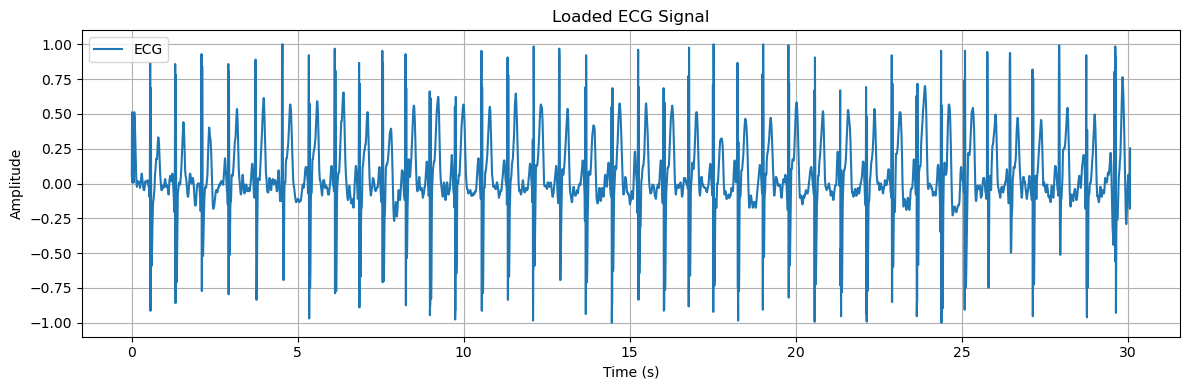

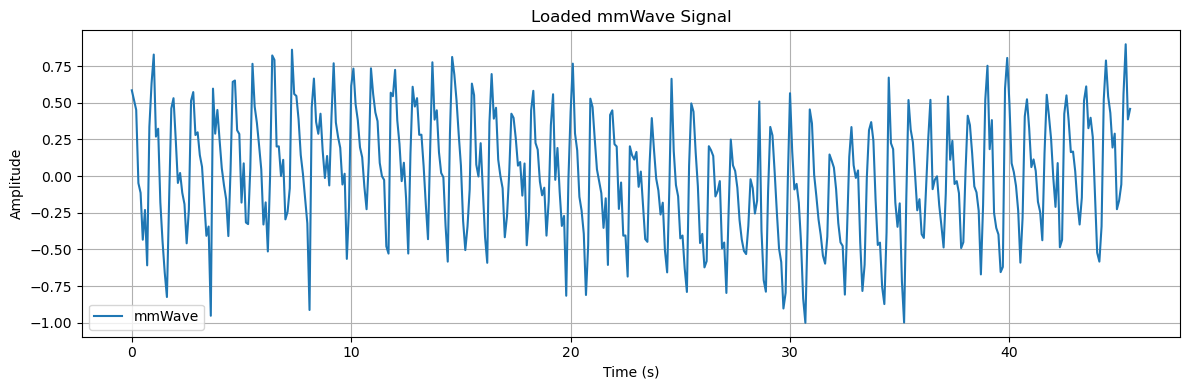

In [5]:
if __name__ == "__main__": #test
    import os
    cwd = os.getcwd()
    path=os.path.join(cwd, 'data','sample_1')
    print(path)
    df_ecg, fs_Hz, info = load_ecg_csv(path+'/1_1lead.csv') #read ecg
    res = ecg_hr_csv_like_scp(path+'/1_1lead.csv')
    res['hr_smooth_0p10s_bpm']


    summary = process_vitals_folder(path, outdir="outputs") # read mmv floder
    df_mmv= transform_to_dataframe(summary) 

    df_ecg_fixed = normalize_ts(df_ecg, y_candidates=('wave',), dt=None)
    pltot_fixed(df_ecg_fixed, title='Loaded ECG Signal', label='ECG')
    df_mmv_fixed = normalize_ts(df_mmv, y_candidates=('mmv','mmwave','heartbeat','value','signal'), dt=0.1)
    pltot_fixed(df_mmv_fixed, title='Loaded mmWave Signal', label='mmWave')



In [6]:
# input folder get sub folder (sample_n) 
import os
from pathlib import Path
import re

def get_sample_subdirs(root):
    root = Path(root)
    patt = re.compile(r"sample_\d+$")   # sample_1, sample_2, ...
    subs = [p for p in root.iterdir() if p.is_dir() and patt.fullmatch(p.name)]
    # sort by the numeric suffix
    subs.sort(key=lambda p: int(p.name.split("_")[1]))
    return subs

path= os.getcwd()+'/data'
# example
all_sample_wave=[] # [folder_name,ecg,mmw,rebuilding]
for p in get_sample_subdirs(path):
    print(p)
    # read ecg
    df_ecg, fs_Hz, info = load_ecg_csv(str(p)+'/1_1lead.csv') #read ecg
    res = ecg_hr_csv_like_scp(str(p)+'/1_1lead.csv')
    
    # read mmv
    summary = process_vitals_folder(p, outdir="outputs") # read mmv floder
    df_mmv= transform_to_dataframe(summary) 
    df_ecg_fixed = normalize_ts(df_ecg, y_candidates=('wave',), dt=None)
    df_mmv_fixed = normalize_ts(df_mmv, y_candidates=('mmv','mmwave','heartbeat','value','signal'), dt=0.1)
    all_sample_wave.append({'path':p,'ecg':df_ecg_fixed,'mmv':df_mmv_fixed,'summary':summary,'ecg_hr_res':res['hr_smooth_0p10s_bpm']})
    print(f'size of ecg: {len(df_ecg_fixed)}, size of mmv: {len(df_mmv_fixed)}, hr from ecg: {res["hr_smooth_0p10s_bpm"]}')


e:\重要文件\毫米波\radar-heartbeat-detection\experiment\data\sample_0
HR(raw)=84.7 bpm
HR(butter 5-15Hz)=84.5 bpm
HR(smooth 0.10s)=81.1 bpm
HR(mean of available)=83.4 bpm
size of ecg: 4512, size of mmv: 290, hr from ecg: 81.13184604461216
e:\重要文件\毫米波\radar-heartbeat-detection\experiment\data\sample_1
HR(raw)=79.2 bpm
HR(butter 5-15Hz)=80.1 bpm
HR(smooth 0.10s)=78.6 bpm
HR(mean of available)=79.3 bpm
size of ecg: 4512, size of mmv: 456, hr from ecg: 78.625101003012
e:\重要文件\毫米波\radar-heartbeat-detection\experiment\data\sample_2
HR(raw)=80.4 bpm
HR(butter 5-15Hz)=80.9 bpm
HR(smooth 0.10s)=80.4 bpm
HR(mean of available)=80.6 bpm
size of ecg: 4512, size of mmv: 396, hr from ecg: 80.37200960163266
e:\重要文件\毫米波\radar-heartbeat-detection\experiment\data\sample_3
HR(raw)=89.7 bpm
HR(butter 5-15Hz)=90.1 bpm
HR(smooth 0.10s)=86.9 bpm
HR(mean of available)=88.9 bpm
size of ecg: 4512, size of mmv: 370, hr from ecg: 86.88384619834756
e:\重要文件\毫米波\radar-heartbeat-detection\experiment\data\sample_4
HR(raw)=89.

e:\重要文件\毫米波\radar-heartbeat-detection\experiment\data\sample_181
size of ecg: 4512, size of mmv: 420


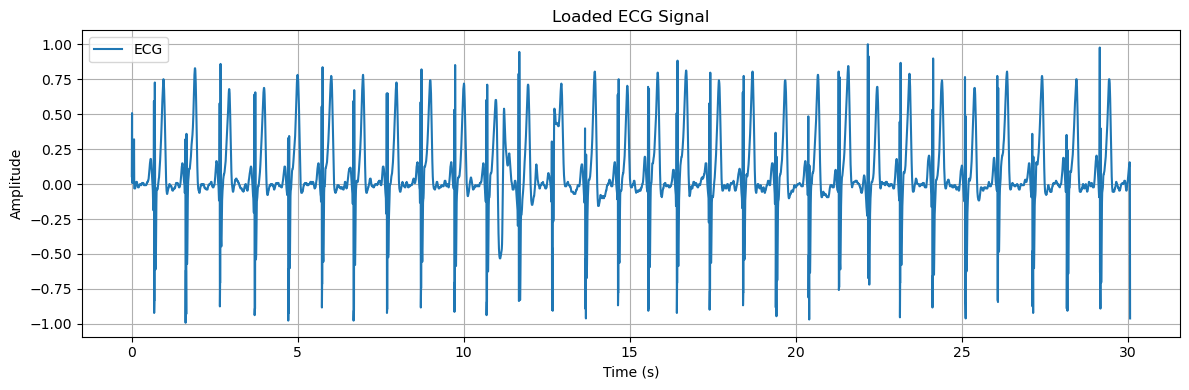

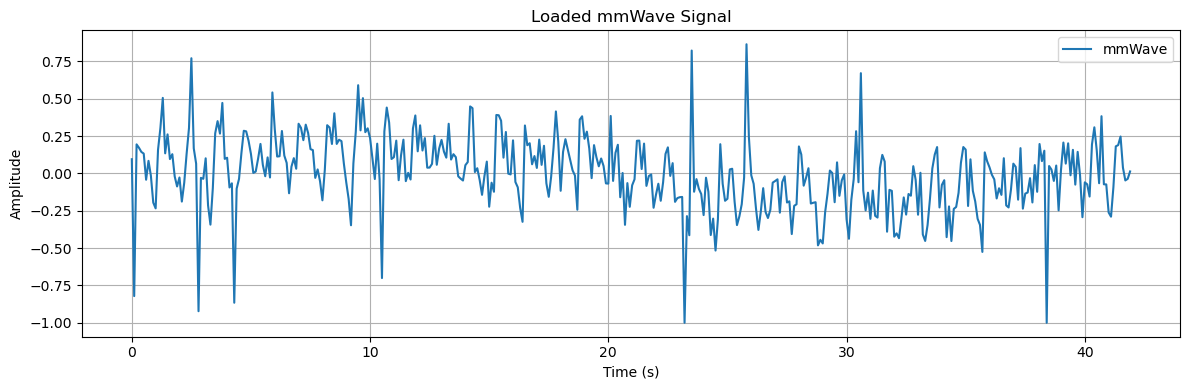

In [7]:
for i in all_sample_wave:
    pass
print(i['path'])
print(f'size of ecg: {len(i["ecg"])}, size of mmv: {len(i["mmv"])}')
pltot_fixed(i['ecg'], title='Loaded ECG Signal', label='ECG')
pltot_fixed(i['mmv'], title='Loaded mmWave Signal', label='mmWave')


## preprocessing

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import savgol_filter, stft, istft, iirnotch, butter, filtfilt
from scipy.signal import hilbert

# ===== 公用工具（中文註解）=====
def bandpass(sig, fs, lo=0.8, hi=3.0, order=4): # 帶通濾波：心跳頻段 (0.8–3.0 Hz)
    # 帶通濾波：心跳頻段 (0.8–3.0 Hz)
    ny = 0.5*fs
    b, a = butter(order, [lo/ny, hi/ny], btype='band')
    return filtfilt(b, a, sig)

def notch_at(sig, fs, f0, Q=30): # 陷波：抑制呼吸基頻與其諧波
    # 陷波：抑制呼吸基頻與其諧波
    if f0 <= 0 or f0 >= fs/2:
        return sig
    b, a = iirnotch(w0=f0/(fs/2), Q=Q)
    return filtfilt(b, a, sig)

def peak_hr_bpm(x, fs, lo=0.8, hi=3.0):  # 頻域主峰估 HR（粗略）
    # 頻域主峰估 HR（粗略）
    n = len(x)
    f = np.fft.rfftfreq(n, 1/fs)
    X = np.abs(np.fft.rfft(x))
    band = (f>=lo) & (f<=hi)
    if not np.any(band):
        return np.nan
    idx = np.argmax(X[band])
    f_pk = f[band][idx]
    return f_pk*60.0

def agc_rms(x, fs, target_rms=0.6, attack_ms=30, release_ms=200, eps=1e-12):
    # 自動增益控制：讓振幅看起來一致（可選）
    a = np.exp(-1.0/(fs*attack_ms/1000.0))
    r = np.exp(-1.0/(fs*release_ms/1000.0))
    y = np.zeros_like(x, dtype=float)
    env = 0.0
    for i, xi in enumerate(x):
        e2 = xi*xi
        if e2 > env:
            env = a*env + (1-a)*e2
        else:
            env = r*env + (1-r)*e2
        g = target_rms/(np.sqrt(env)+eps)
        y[i] = xi*g
    return y

def envelope_norm(x, q=0.8, eps=1e-12):
    # 以 Hilbert 包絡做分位數正規化（可選，避免尖峰主導）
    env = np.abs(hilbert(x))
    scale = np.quantile(env, q)+eps
    return x/scale

def plot_triplet(t, x_raw, x_filt, title, overlay_alpha=0.9, ylims=None):
    # 三聯圖：Raw / Filtered / Overlay（全英文抬頭）
    fig, axes = plt.subplots(1, 3, figsize=(14, 3), sharex=True)
    axes[0].plot(t, x_raw, linewidth=1)
    axes[0].set_title("Raw")
    axes[1].plot(t, x_filt, linewidth=1)
    axes[1].set_title("Filtered")
    axes[2].plot(t, x_raw, linewidth=1, label="Raw")
    axes[2].plot(t, x_filt, linewidth=1, alpha=overlay_alpha, label="Filtered")
    axes[2].set_title("Overlay"); axes[2].legend(loc="upper right")
    for ax in axes:
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Amplitude")
        if ylims is not None:
            ax.set_ylim(ylims)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# ===== 方法實作（中文註解）=====
def method_bandpass(x, fs):
    # 基礎帶通
    return bandpass(x, fs, 0.8, 3.0)

def method_bp_notch(x, fs, rr_bpm):
    # 帶通 + 在呼吸與二次諧波處陷波
    y = bandpass(x, fs, 0.8, 3.0)
    rr_hz = rr_bpm/60.0
    y = notch_at(y, fs, rr_hz, Q=35)
    y = notch_at(y, fs, 2*rr_hz, Q=35)
    return y

def method_sg_bp(x, fs, win_sec=0.5, poly=3):
    # Savitzky–Golay 平滑 + 帶通
    win = int(max(5, np.floor(win_sec*fs)//2*2+1))  # 強制奇數
    y = savgol_filter(x, window_length=win, polyorder=poly, mode='interp')
    y = bandpass(y, fs, 0.8, 3.0)
    return y

def method_ssa_band_select(x, fs, embed=200, rank_max=12, lo=0.8, hi=3.0):
    # SSA：Hankel->SVD->重建前r成分->只保留主頻落在心跳帶的成分
    N = len(x)
    L = int(min(embed, N//2))
    K = N - L + 1
    X = np.column_stack([x[i:i+L] for i in range(K)])
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    r = min(rank_max, len(s))
    comps = []
    for i in range(r):
        Hi = np.outer(U[:, i]*s[i], Vt[i, :])
        y = np.zeros(N); cnt = np.zeros(N)
        for d in range(-L+1, K):
            diag_vals = np.diag(Hi, k=d)
            idxs = np.arange(max(0, -d), min(L, K-d)) + max(0, d)
            y[idxs] += diag_vals; cnt[idxs] += 1
        comps.append(y/(cnt+1e-12))
    sel = np.zeros(N)
    for y in comps:
        hr = peak_hr_bpm(y, fs, lo, hi)
        if np.isfinite(hr):
            sel += y
    return bandpass(sel, fs, lo, hi)

def method_specsub_bp(x, fs, nperseg=None, noverlap=None, alpha=1.0, floor=0.1):
    # 動態設定：對低取樣率/短序列更穩
    N = len(x)
    if nperseg is None:
        nperseg = max(32, min(256, int(round(4*fs))))  # ≈4秒窗，上限256
    nperseg = int(min(nperseg, N)) if N > 0 else 32
    if noverlap is None:
        noverlap = int(0.75 * nperseg)
    noverlap = max(0, min(noverlap, nperseg - 1))

    # STFT（允許補零），避免邊界裁切
    f, t, Z = stft(x, fs=fs, nperseg=nperseg, noverlap=noverlap,
                   boundary='zeros')  # ← 重點

    mag = np.abs(Z); ph = np.angle(Z)
    noise = np.median(mag, axis=1, keepdims=True)
    mag_hat = np.maximum(mag - alpha*noise, floor*noise)
    Z_hat = mag_hat * np.exp(1j*ph)

    # ISTFT 用同參數還原（同樣允許補零）
    _, y = istft(Z_hat, fs=fs, nperseg=nperseg, noverlap=noverlap,
                 boundary='zeros')    # ← 重點
    y = y[:N]  # 對齊原長度
    return bandpass(y, fs, 0.8, 3.0)

def method_ale(x, fs, D=6, M=14, mu=0.01):
    # 自適應線性增強器（LMS）
    N = len(x); w = np.zeros(M); y = np.zeros(N)
    ref = np.zeros(N); ref[D:] = x[:-D]
    for n in range(M, N):
        u = ref[n-M:n][::-1]
        y[n] = np.dot(w, u)
        e = x[n] - y[n]
        w += 2*mu*e*u
    return bandpass(y, fs, 0.8, 3.0)

# ===== Kalman 濾波（中文註解）=====
def kalman_1d(x, q_scale=1e-4, r_scale=1e-2, smooth=True):
    """
    一維卡爾曼：狀態 x_k = x_{k-1} + w_k，量測 z_k = x_k + v_k
    Q = q_scale*var(x), R = r_scale*var(x)
    smooth=True 時回傳 RTS 平滑結果，否則回傳前向濾波
    """
    x = np.asarray(x, dtype=float)
    N = len(x)
    if N == 0:
        return x

    var = np.var(x) + 1e-12
    Q = q_scale * var
    R = r_scale * var

    # 前向濾波
    x_pred = np.zeros(N)
    P_pred = np.zeros(N)
    x_filt = np.zeros(N)
    P_filt = np.zeros(N)

    # 初始化
    x_filt[0] = x[0]
    P_filt[0] = var

    for k in range(1, N):
        # predict
        x_pred[k] = x_filt[k-1]
        P_pred[k] = P_filt[k-1] + Q
        # update
        K = P_pred[k] / (P_pred[k] + R)
        x_filt[k] = x_pred[k] + K * (x[k] - x_pred[k])
        P_filt[k] = (1 - K) * P_pred[k]

    if not smooth:
        return x_filt

    # RTS 平滑
    x_smooth = np.copy(x_filt)
    P_smooth = np.copy(P_filt)
    for k in range(N-2, -1, -1):
        C = P_filt[k] / (P_pred[k+1] + 1e-12)
        x_smooth[k] = x_filt[k] + C * (x_smooth[k+1] - x_pred[k+1])
        P_smooth[k] = P_filt[k] + C**2 * (P_smooth[k+1] - P_pred[k+1])
    return x_smooth

def method_kalman_then_bp(x, fs, q_scale=1e-4, r_scale=1e-2, smooth=True):
    # 先卡爾曼平滑原始訊號，再帶通到心跳帶
    xd = signal.detrend(x, type="linear")
    xk = kalman_1d(xd, q_scale=q_scale, r_scale=r_scale, smooth=smooth)
    return bandpass(xk, fs, 0.8, 3.0)

def method_bp_then_kalman(x, fs, q_scale=5e-5, r_scale=5e-3, smooth=True):
    # 先帶通聚焦心跳，再用卡爾曼去除殘餘雜訊與波紋
    y = bandpass(x, fs, 0.8, 3.0)
    yk = kalman_1d(y, q_scale=q_scale, r_scale=r_scale, smooth=smooth)
    return yk

# ==== 新增：中值 / 小波 / AMP ====
from scipy.signal import medfilt
try:
    import pywt  # pip install PyWavelets
except ImportError:
    pywt = None

def method_median(x, fs, ksize=5):
    k = int(max(3, ksize // 2 * 2 + 1))          # 強制奇數
    y = medfilt(x, kernel_size=k)
    return bandpass(y, fs, 0.8, 3.0)

def method_wavelet(x, fs, wavelet='db4', level=3):
    if pywt is None:
        # 沒裝 PyWavelets 時退化為 bandpass
        return bandpass(x, fs, 0.8, 3.0)
    coeffs = pywt.wavedec(x, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745 + 1e-12
    thr = sigma * np.sqrt(2 * np.log(len(x)))
    coeffs = [pywt.threshold(c, value=thr, mode='soft') for c in coeffs]
    y = pywt.waverec(coeffs, wavelet)[:len(x)]
    return bandpass(y, fs, 0.8, 3.0)

def method_amp(x, fs, win_sec=1.0):
    n = max(3, int(round(win_sec * fs)))
    k = np.ones(n) / n
    y = np.convolve(x, k, mode="same")
    return bandpass(y, fs, 0.8, 3.0)

# ==== 強化：STFT 參數安全性（避免長度不符）====
def method_specsub_bp(x, fs, nperseg=256, noverlap=192, alpha=1.0, floor=0.1):
    N = len(x)
    # nperseg 不可超過長度，且 noverlap < nperseg
    nps = int(min(max(32, nperseg), N if N > 0 else 32))
    nov = int(min(max(0, noverlap), nps - 1))
    f, t, Z = stft(x, fs=fs, nperseg=nps, noverlap=nov, boundary=None)
    mag = np.abs(Z); ph = np.angle(Z)
    noise = np.median(mag, axis=1, keepdims=True)
    mag_hat = np.maximum(mag - alpha*noise, floor*noise)
    Z_hat = mag_hat * np.exp(1j*ph)
    _, y = istft(Z_hat, fs=fs, nperseg=nps, noverlap=nov, boundary=None)
    y = y[:len(x)]
    return bandpass(y, fs, 0.8, 3.0)




In [9]:
import re
import numpy as np
import pandas as pd

# 依你前面定義的方法與參數
# Methods list (display_name, function, kwargs)
rr_bpm_for_notch=14
methods = [
    ("Baseline Bandpass",              method_bandpass,        dict()),
    ("BP + Notch @ rr & 2rr",          method_bp_notch,        dict(rr_bpm=rr_bpm_for_notch)),
    ("Savitzky–Golay + BP",            method_sg_bp,           dict(win_sec=0.5, poly=3)),
    ("Median + BP",                    method_median,          dict(ksize=5)),
    ("Wavelet + BP",                   method_wavelet,         dict(wavelet='db4', level=3)),
    ("AMP + BP",                       method_amp,             dict(win_sec=1.0)),
    ("SSA Band-Selected + BP",         method_ssa_band_select, dict(embed=200, rank_max=12, lo=0.8, hi=3.0)),
    ("STFT Spectral Subtraction + BP", method_specsub_bp,      dict(nperseg=256, noverlap=192, alpha=1.0, floor=0.1)),
    ("ALE Adaptive Enhancer + BP",     method_ale,             dict(D=6, M=14, mu=0.01)),
    ("Kalman → Bandpass",              method_kalman_then_bp,  dict(q_scale=1e-4, r_scale=1e-2, smooth=True)),
    ("Bandpass → Kalman",              method_bp_then_kalman,  dict(q_scale=5e-5, r_scale=5e-3, smooth=True)),
]
# 可選旗標：use_agc, use_env_norm, rr_bpm_for_notch 已在你上方定義
# ===== 批次處理 + 圖 + HR 表 =====
def run_and_summarize(t, x, fs, methods, use_agc=False, use_env_norm=False, fixed_ylim=None):
    rows = []
    print("=== Estimated HR by spectral peak within [0.8, 3.0] Hz (BPM) ===")
    for name, fn, kw in methods:
        y = fn(x, fs, **kw)
        if use_agc:     y = agc_rms(y, fs, target_rms=0.6, attack_ms=30, release_ms=200)
        if use_env_norm:y = envelope_norm(y, q=0.8)
        # 圖
        plot_triplet(t, x, y, title=name, ylims=fixed_ylim)
        # HR
        est = peak_hr_bpm(y, fs)
        print(f"{name:32s}: {est:6.2f}")
        rows.append({"method": name, "est_hr_bpm": est})
    return pd.DataFrame(rows)
def _fs_from_t(t):
    dt = np.nanmedian(np.diff(t)) if len(t) > 1 else np.nan
    return float(1.0/dt) if np.isfinite(dt) and dt > 0 else 10.0

def _sanitize_key(name):
    key = name.lower()
    key = re.sub(r'[^a-z0-9]+', '_', key).strip('_')
    return key

def build_preprocessing(all_sample_wave, methods):
    for it in all_sample_wave:
        df_mmv = it["mmv"]         # expects columns: t_sec, wave
        t = df_mmv["t_sec"].to_numpy(float)
        x = df_mmv["wave"].to_numpy(float)
        fs = _fs_from_t(t)

        x_in = x.copy()
        if 'use_agc' in globals() and use_agc:
            x_in = agc_rms(x_in, fs)
        if 'use_env_norm' in globals() and use_env_norm:
            x_in = envelope_norm(x_in, q=0.8)

        pre = {}
        for disp_name, func, kwargs in methods:
            key = _sanitize_key(disp_name)
            y = func(x_in, fs, **kwargs)
            pre[key] = pd.DataFrame({"t_sec": t, "wave": y})

        it["pre_processing"] = pre

# 執行
build_preprocessing(all_sample_wave, methods)

# 使用示例：
all_sample_wave[0]["pre_processing"].keys()  # 查看有哪些預處理方法

C:\Users\op237\AppData\Local\Temp\ipykernel_64564\3202524534.py:254: UserWarning: NOLA condition failed, STFT may not be invertible. Possibly due to missing boundary
  _, y = istft(Z_hat, fs=fs, nperseg=nps, noverlap=nov, boundary=None)


dict_keys(['baseline_bandpass', 'bp_notch_rr_2rr', 'savitzky_golay_bp', 'median_bp', 'wavelet_bp', 'amp_bp', 'ssa_band_selected_bp', 'stft_spectral_subtraction_bp', 'ale_adaptive_enhancer_bp', 'kalman_bandpass', 'bandpass_kalman'])

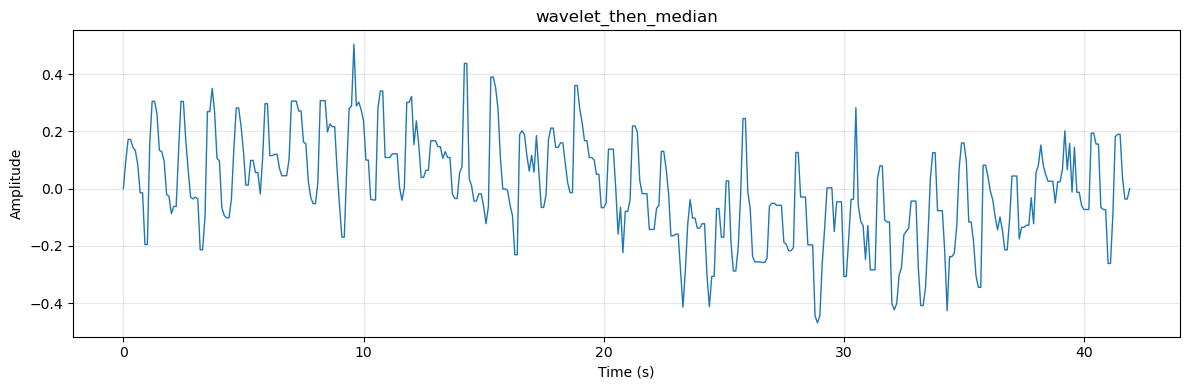

In [10]:
# === 四種基礎處理 ===
from scipy.signal import medfilt

try:
    import pywt
except ImportError:
    pywt = None

def step_bp(x, fs, lo=0.05, hi=15.0):
    ny = 0.5 * fs

    # 自動 clamp
    hi_eff = min(hi, ny * 0.99)
    lo_eff = max(lo, 0.01)

    if hi_eff <= lo_eff:
        hi_eff = lo_eff + 0.01

    return bandpass(x, fs, lo_eff, hi_eff)

def step_median(x, fs, ksize=5):
    k = int(max(3, ksize//2*2+1))      # 奇數
    return medfilt(x, kernel_size=k)

def step_wavelet(x, fs, wavelet='db4', level=3):
    if pywt is None:
        return x
    coeffs = pywt.wavedec(x, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745 + 1e-12
    thr = sigma * np.sqrt(2*np.log(len(x)))
    coeffs = [pywt.threshold(c, value=thr, mode='soft') for c in coeffs]
    y = pywt.waverec(coeffs, wavelet)[:len(x)]
    return y

def step_amp(x, fs, win_sec=1.0):
    n = max(3, int(round(win_sec*fs)))
    k = np.ones(n)/n
    return np.convolve(x, k, mode='same')

# === 可組合：建立 12 組有序雙步管線 A→B ===
from itertools import permutations
import re, numpy as np, pandas as pd

PRIMS = {
    # 中值濾波：只去除極端脈衝雜訊
    "median":   lambda x, fs: step_median(x, fs, ksize=3),  # 5→3 更保守
    
    # 小波去噪：只去除高頻雜訊，保留所有生理範圍
    "wavelet":  lambda x, fs: step_wavelet(x, fs, wavelet='db4', level=2),  # 3→2 保留更多細節
    
    # 振幅標準化：保持不變（不影響頻譜結構）
    "amp":      lambda x, fs: step_amp(x, fs, win_sec=1.0),
    
    # 帶通濾波：極寬鬆範圍，只去除 DC 和極低頻漂移
    "bp":       lambda x, fs: step_bp(x, fs, lo=0.05, hi=15.0),
}

PIPELINES = []
for a, b in permutations(PRIMS.keys(), 2):   # 有序排列，不含同名連續
    name = f"{a}_then_{b}"
    fn = (lambda A=a, B=b: (lambda x, fs: PRIMS[B](PRIMS[A](x, fs), fs)))()
    PIPELINES.append((name, fn))

def _fs_from_t(t):
    dt = np.nanmedian(np.diff(t)) if len(t) > 1 else np.nan
    return float(1.0/dt) if np.isfinite(dt) and dt > 0 else 10.0

def _sanitize_key(name):
    return re.sub(r'[^a-z0-9]+', '_', name.lower()).strip('_')

def build_pairwise_preproc(all_sample_wave):
    """
    將 12 組 A→B 管線套到每個樣本的 mmv，輸出到 it['pre_processing'][key]=DataFrame(t_sec,wave)
    """
    for it in all_sample_wave:
        df_mmv = it["mmv"]                       # 需要欄位: t_sec, wave
        t = pd.to_numeric(df_mmv["t_sec"], errors="coerce").to_numpy(dtype=float)
        x = pd.to_numeric(df_mmv["wave"],  errors="coerce").to_numpy(dtype=float)
        m = np.isfinite(t) & np.isfinite(x)
        t, x = t[m], x[m]
        fs = _fs_from_t(t)

        pre = {}
        for name, fn in PIPELINES:
            y = fn(x, fs)
            if len(y) != len(t):
                y = y[:len(t)]
            key = _sanitize_key(name)
            pre[key] = pd.DataFrame({"t_sec": t, "wave": y})

        it["pre_processing"] = pre
        # 可視需要印出
        # print(it['path'], "pairs:", list(pre.keys()))

# 執行
build_pairwise_preproc(all_sample_wave)

# 取最後一組並畫圖（示例）
last = all_sample_wave[-1]
last_key = sorted(last["pre_processing"].keys())[-1]
df_last = last["pre_processing"][last_key]
plt.figure(figsize=(12,4))
plt.plot(df_last["t_sec"], df_last["wave"], lw=1)
plt.title(f"{last_key}")
plt.xlabel("Time (s)"); plt.ylabel("Amplitude"); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [11]:
import numpy as np
import pandas as pd

for num in all_sample_wave:
    pre = num.get('pre_processing', {})
    if not pre:
        continue

    num.setdefault('preproc_wave', {})  # 只存處理後的波形
    for mkey, df_pp in pre.items():
        # 僅保留 t_sec、wave，原樣放入
        df_pp2 = pd.DataFrame({
            "t_sec": pd.to_numeric(df_pp["t_sec"], errors="coerce"),
            "wave":  pd.to_numeric(df_pp["wave"],  errors="coerce"),
        }).dropna(subset=["t_sec","wave"]).reset_index(drop=True)

        num['preproc_wave'][mkey] = df_pp2

    print(num['path'], "methods stored:", list(num['preproc_wave'].keys()))

e:\重要文件\毫米波\radar-heartbeat-detection\experiment\data\sample_0 methods stored: ['median_then_wavelet', 'median_then_amp', 'median_then_bp', 'wavelet_then_median', 'wavelet_then_amp', 'wavelet_then_bp', 'amp_then_median', 'amp_then_wavelet', 'amp_then_bp', 'bp_then_median', 'bp_then_wavelet', 'bp_then_amp']
e:\重要文件\毫米波\radar-heartbeat-detection\experiment\data\sample_1 methods stored: ['median_then_wavelet', 'median_then_amp', 'median_then_bp', 'wavelet_then_median', 'wavelet_then_amp', 'wavelet_then_bp', 'amp_then_median', 'amp_then_wavelet', 'amp_then_bp', 'bp_then_median', 'bp_then_wavelet', 'bp_then_amp']
e:\重要文件\毫米波\radar-heartbeat-detection\experiment\data\sample_2 methods stored: ['median_then_wavelet', 'median_then_amp', 'median_then_bp', 'wavelet_then_median', 'wavelet_then_amp', 'wavelet_then_bp', 'amp_then_median', 'amp_then_wavelet', 'amp_then_bp', 'bp_then_median', 'bp_then_wavelet', 'bp_then_amp']
e:\重要文件\毫米波\radar-heartbeat-detection\experiment\data\sample_3 methods store

Plotting from: e:\重要文件\毫米波\radar-heartbeat-detection\experiment\data\sample_181


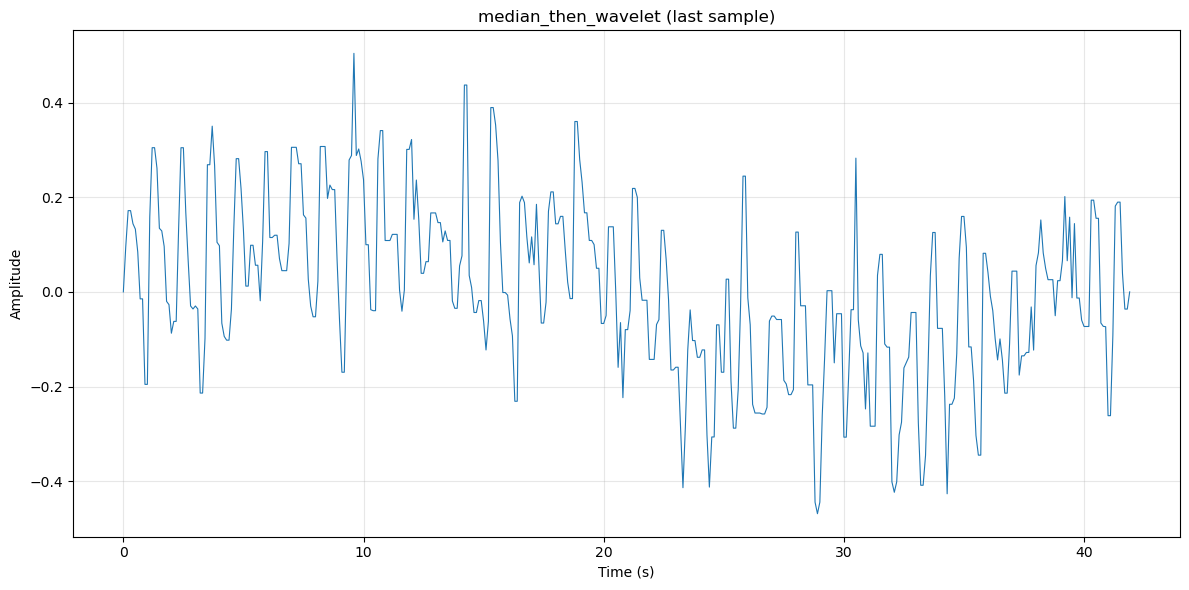

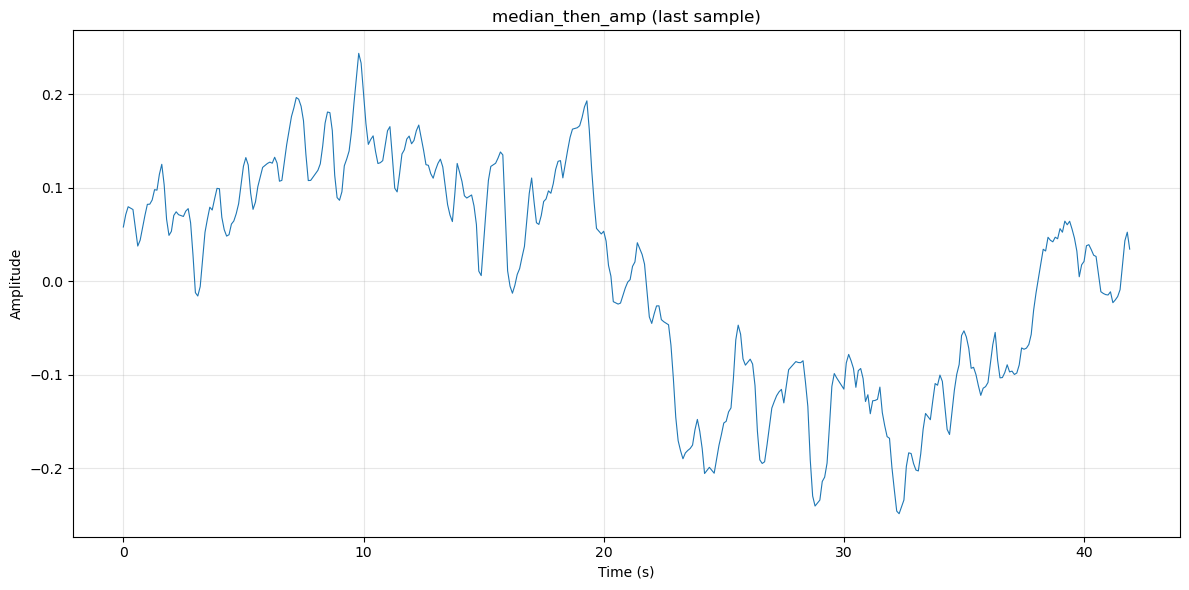

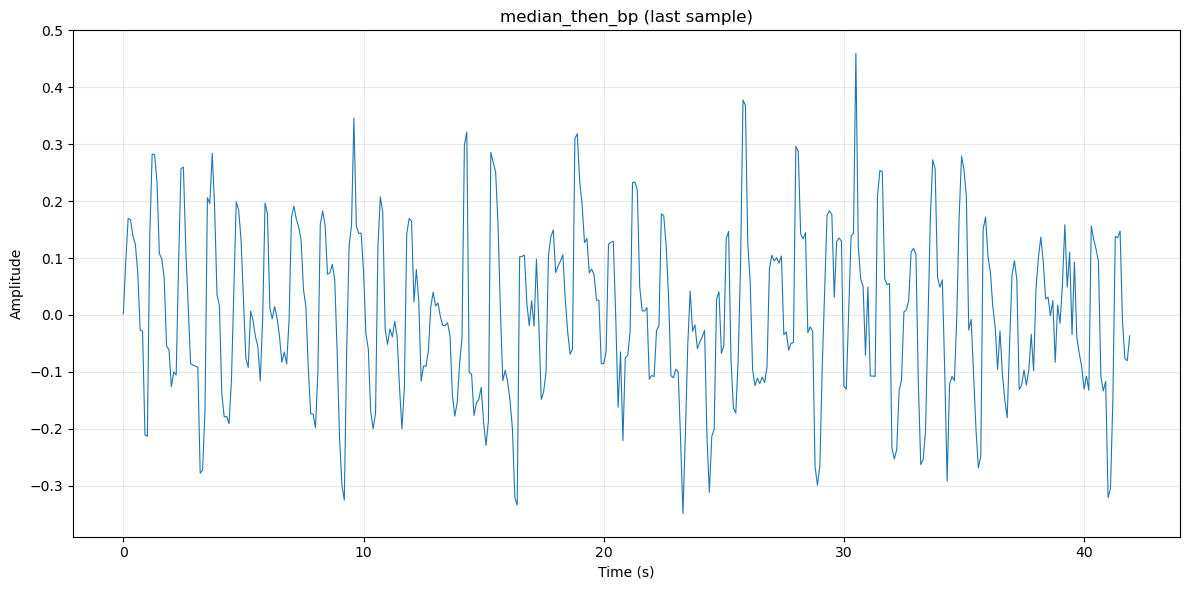

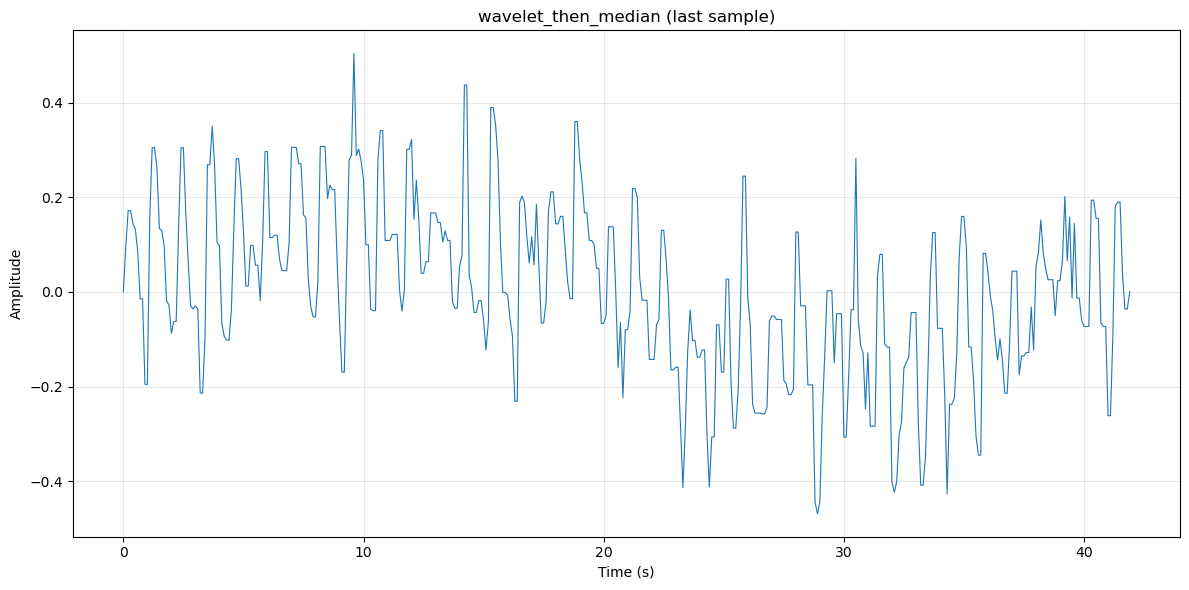

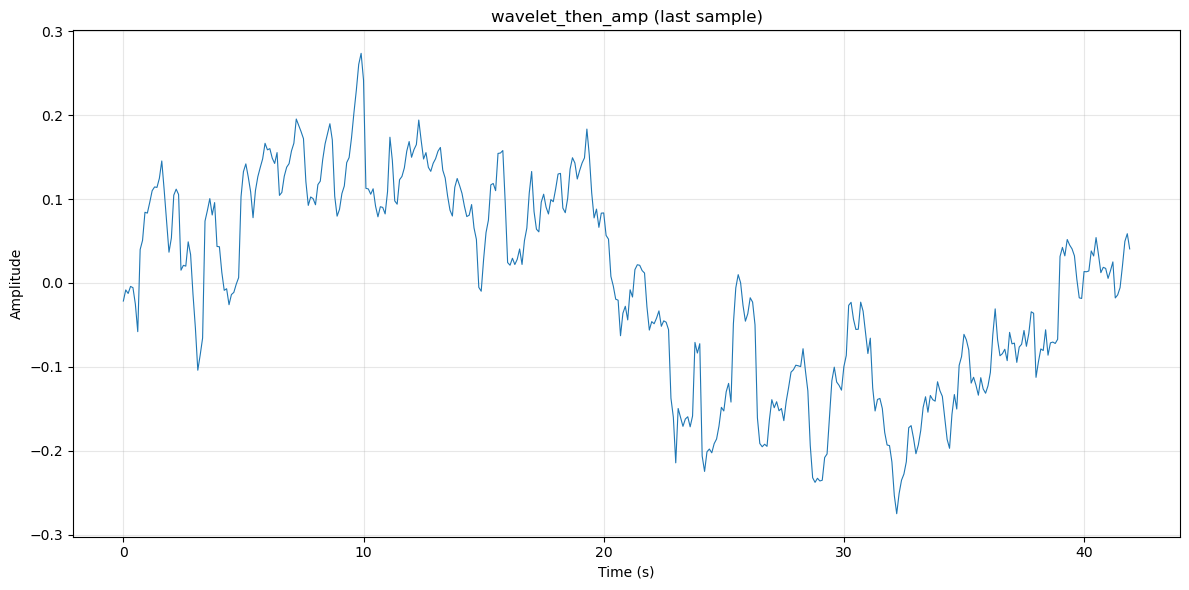

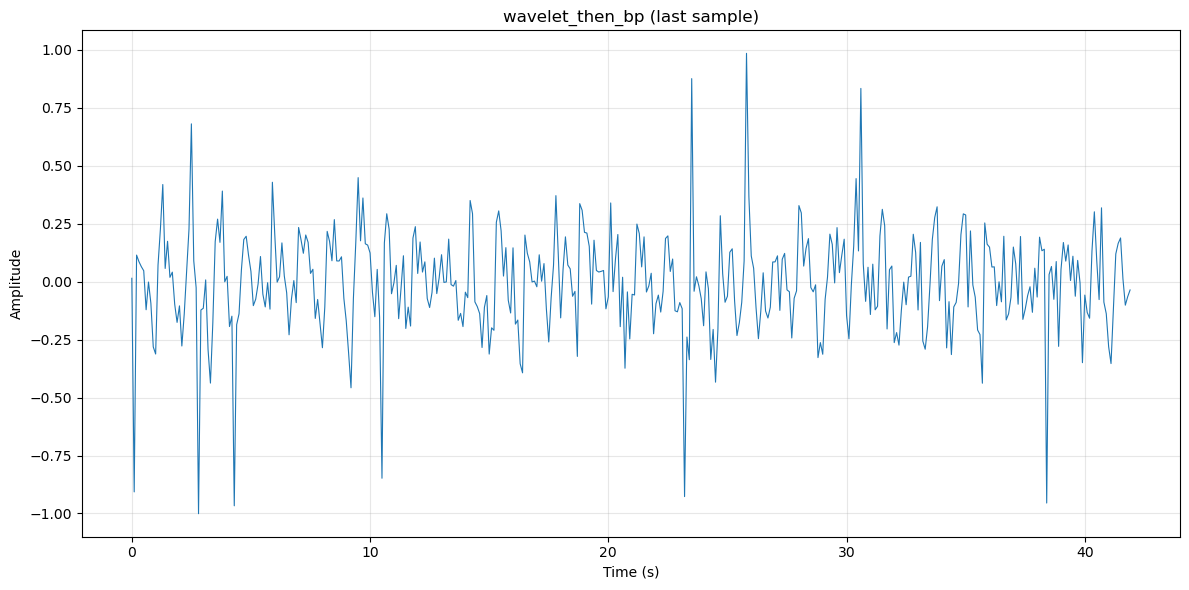

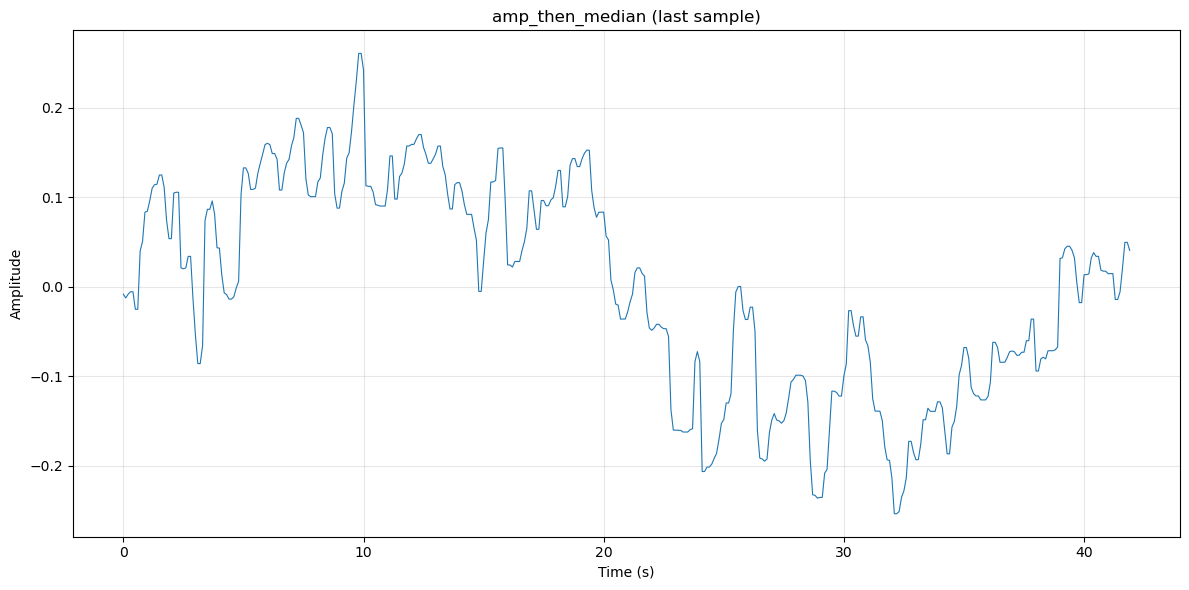

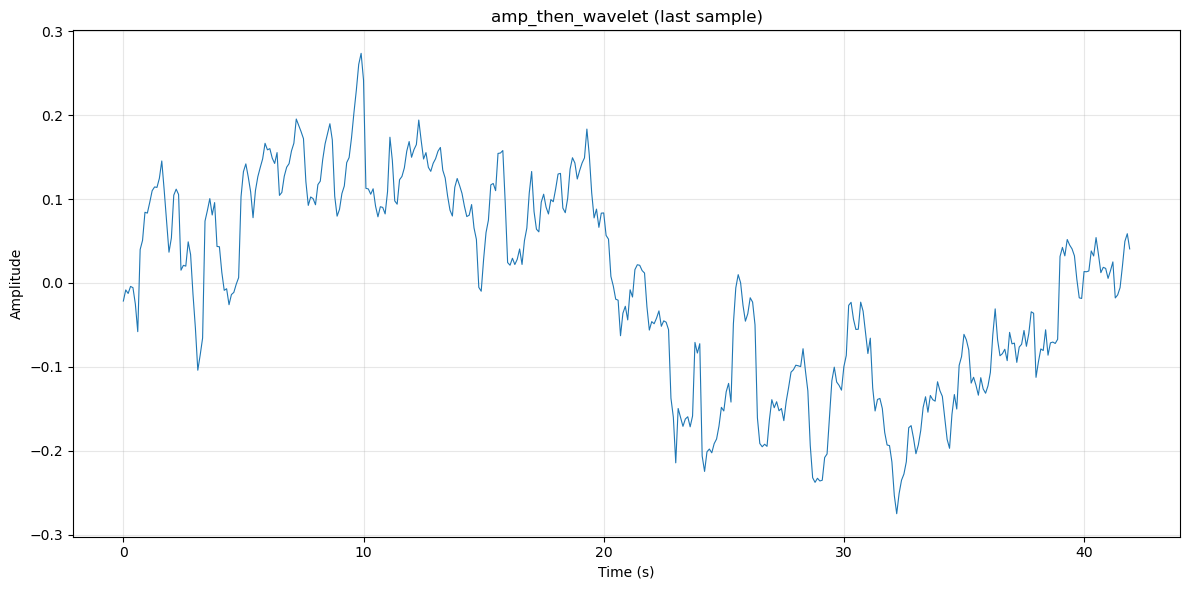

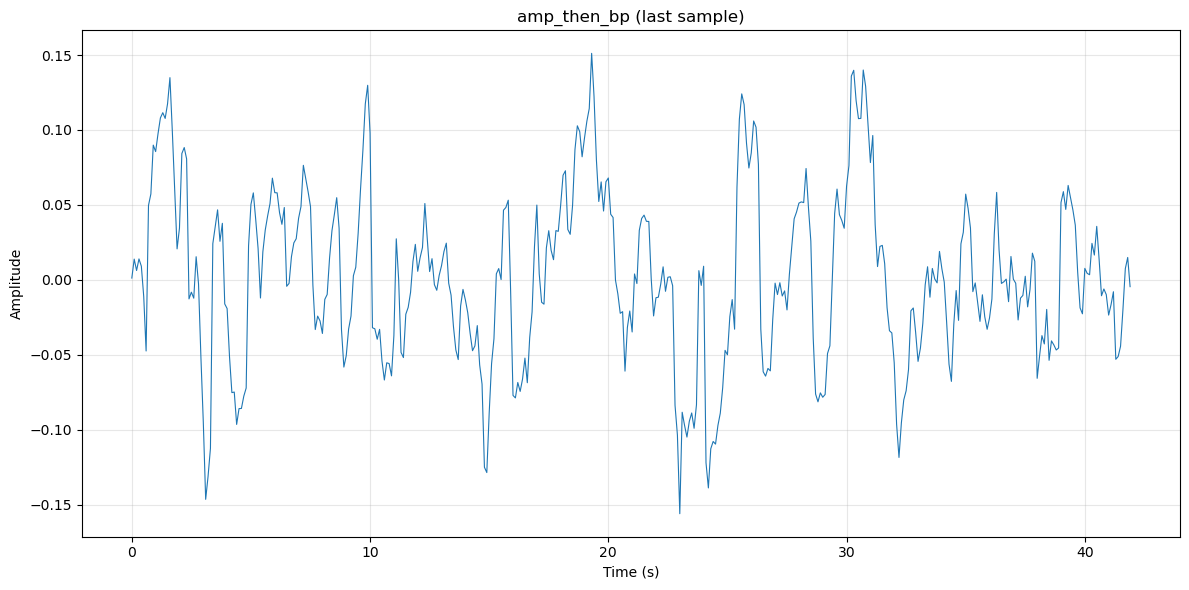

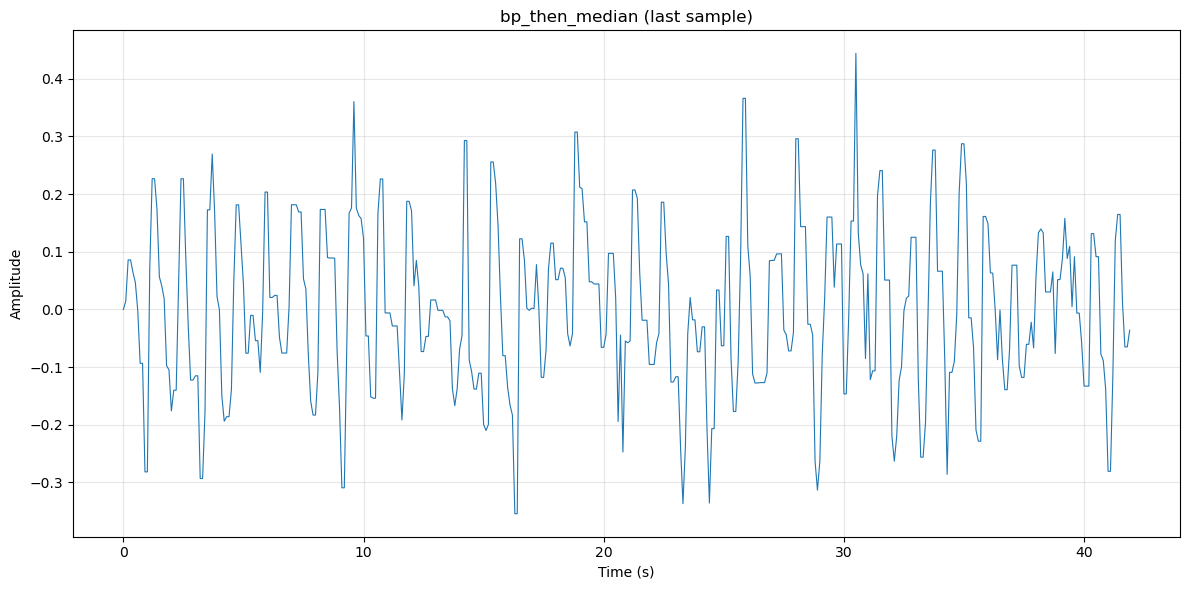

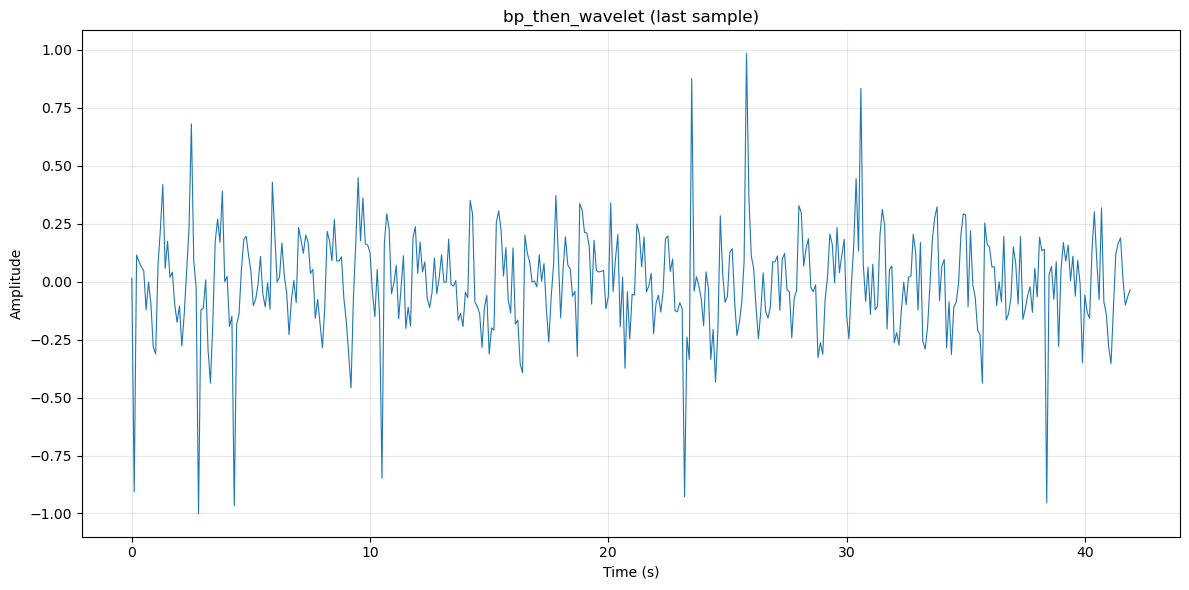

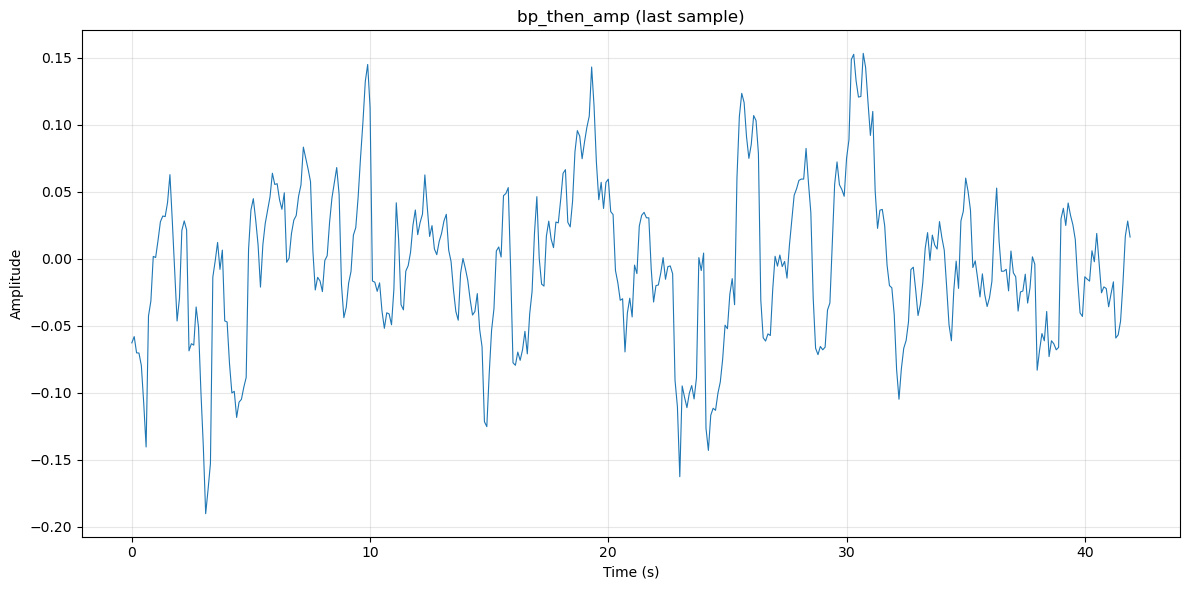

In [12]:
import matplotlib.pyplot as plt

# 找出最後一個 sample
num = all_sample_wave[-1]
preproc = num.get("preproc_wave", {})

if not preproc:
    print("no preproc_wave found in last sample")
else:
    print("Plotting from:", num["path"])
    for name, df in preproc.items():
        t = df["t_sec"].to_numpy(float)
        y = df["wave"].to_numpy(float)
        plt.figure(figsize=(12, 6))
        plt.plot(t, y, lw=0.8)
        plt.title(f"{name} (last sample)")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

In [13]:
import os
import matplotlib.pyplot as plt
import numpy as np

# 建立 plots 資料夾
save_dir = "plots"
os.makedirs(save_dir, exist_ok=True)

def gcc_phat(sig, refsig, fs, max_tau=None, eps=1e-15):
    n = sig.size + refsig.size
    SIG = np.fft.rfft(sig, n=n)
    REFSIG = np.fft.rfft(refsig, n=n)
    R = SIG * np.conj(REFSIG)
    R /= (np.abs(R) + eps)
    cc = np.fft.irfft(R, n=n)
    max_shift = n // 2
    cc = np.concatenate((cc[-max_shift:], cc[:max_shift+1]))
    if max_tau is not None:
        max_shift_limit = int(max_tau * fs)
        if max_shift_limit < max_shift:
            center = max_shift
            start = center - max_shift_limit
            end   = center + max_shift_limit + 1
            cc_window = cc[start:end]
            shift_window = np.arange(-max_shift_limit, max_shift_limit + 1)
            best_idx = np.argmax(np.abs(cc_window))
            shift = shift_window[best_idx]
        else:
            shift = np.argmax(np.abs(cc)) - max_shift
    else:
        shift = np.argmax(np.abs(cc)) - max_shift
    tau = shift / fs
    return tau, cc


# 使用最後 sample
num = all_sample_wave[-1]
preproc = num.get("preproc_wave", {})
ecg_df = num.get("ecg", None)

if preproc and ecg_df is not None:
    t_ecg = ecg_df["t_sec"].to_numpy(float)
    ecg = ecg_df["wave"].to_numpy(float)

    dt_ecg = np.median(np.diff(t_ecg))
    fs_ecg = 1.0 / dt_ecg

    items = sorted(preproc.items(), key=lambda kv: kv[0])[:12]

    for name, df in items:
        t = df["t_sec"].to_numpy(float)
        y = df["wave"].to_numpy(float)

        # ---- 名稱格式：TitleCase + AMP/BP 大寫 + then→ ----
        safe = name.replace("_", " ")
        safe = safe.replace("then", "→").replace("Then", "→")
        safe = safe.title()
        safe = safe.replace("Amp", "AMP").replace("Bp", "BP")

        # ---- 重疊 ----
        t0 = max(t_ecg[0], t[0])
        t1 = min(t_ecg[-1], t[-1])
        if t1 <= t0:
            continue

        dt_y = np.median(np.diff(t))
        fs_y = 1.0 / dt_y
        fs = min(fs_ecg, fs_y)

        t_grid = np.arange(t0, t1, 1.0/fs)
        ecg_seg = np.interp(t_grid, t_ecg, ecg)
        y_seg = np.interp(t_grid, t, y)

        ecg_peak = np.max(np.abs(ecg_seg)) + 1e-12
        y_peak = np.max(np.abs(y_seg)) + 1e-12
        amp_scale = ecg_peak / y_peak

        y_scaled = y * amp_scale
        y_seg_scaled = y_seg * amp_scale

        tau, _ = gcc_phat(y_seg_scaled, ecg_seg, fs, max_tau=3.0)

        t_aligned = t - tau
        mask = (t_aligned >= t_ecg[0]) & (t_aligned <= t_ecg[-1])

        # --- 圖 ---
        plt.figure(figsize=(12, 6))
        plt.plot(t_ecg, ecg / ecg_peak, lw=0.8, alpha=0.6, label="ECG")
        plt.plot(t_aligned[mask], (y_scaled / ecg_peak)[mask],
                 lw=0.8, label=safe)

        # 固定右上角 TAG
        plt.legend(loc="upper right")

        plt.title(f"{safe} → Normalized And GCC-PHAT Aligned")
        plt.xlabel("Time (s)")
        plt.ylabel("Normalized Amplitude")
        plt.grid(alpha=0.3)
        plt.tight_layout()

        # --- 儲存檔案 ---
        fname = safe.replace(" ", "_") + ".png"
        path = os.path.join(save_dir, fname)
        plt.savefig(path, dpi=600)

        plt.close()  # 若你希望不顯示圖，可以保留 close()


In [14]:
import numpy as np, pandas as pd, os

# --- helpers ---
def _infer_fs_from_t(t, fallback=10.0):
    t = np.asarray(t, float)
    if t.size > 1:
        dt = np.nanmedian(np.diff(t))
        if np.isfinite(dt) and dt > 0:
            return float(1.0/dt)
    return float(fallback)

def _hr_fft_peak_bpm(y, fs, lo=0.8, hi=3.0):
    y = np.asarray(y, float)
    n = len(y)
    if n < 16 or fs <= 0:
        return np.nan
    w = np.hanning(n)
    Y = np.fft.rfft((y - np.nanmean(y)) * w)
    f = np.fft.rfftfreq(n, 1.0/fs)
    band = (f >= lo) & (f <= hi)
    if not np.any(band):
        return np.nan
    idx = np.nanargmax(np.abs(Y[band]))
    f_pk = f[band][idx]
    return float(f_pk * 60.0)

# --- build long table: sample × method ---
rows = []
for it in all_sample_wave:
    sample = os.path.basename(str(it.get("path","")))
    gt_hr = float(it.get("ecg_hr_res", np.nan))
    pre = it.get("preproc_wave", {}) or {}
    for mkey, dfw in pre.items():
        t = dfw["t_sec"].to_numpy(float)
        x = dfw["wave"].to_numpy(float)
        fs = _infer_fs_from_t(t, fallback=10.0)
        est = _hr_fft_peak_bpm(x, fs, lo=0.8, hi=3.0)
        rows.append({
            "sample": sample,
            "method": mkey,
            "ECG_HR_bpm": gt_hr,
            "Est_HR_bpm": est,
            "Diff_bpm": est - gt_hr if np.isfinite(est) and np.isfinite(gt_hr) else np.nan,
            "AbsErr_bpm": abs(est - gt_hr) if np.isfinite(est) and np.isfinite(gt_hr) else np.nan,
        })

df_long = pd.DataFrame(rows).sort_values(["method","sample"]).reset_index(drop=True)
print(df_long.head())

# --- per-method summary across all samples (累加/平均) ---
method_sum = (
    df_long.groupby("method", as_index=False)
      .agg(
          N=("sample","count"),
          MAE_bpm=("AbsErr_bpm","mean"),
          MdAE_bpm=("AbsErr_bpm","median"),
          RMSE_bpm=("Diff_bpm", lambda s: float(np.sqrt(np.nanmean((s.values)**2)))),
          Bias_bpm=("Diff_bpm","mean"),
          TotalAbsErr_bpm=("AbsErr_bpm","sum")
      )
      .sort_values(["MAE_bpm","RMSE_bpm","TotalAbsErr_bpm"], ascending=[True, True, True])
)
print(method_sum)

# 儲存 
df_long.to_csv("hr_eval_rhythmwave_long.csv", index=False) 
method_sum.to_csv("hr_eval_rhythmwave_method_summary.csv", index=False)


       sample       method  ECG_HR_bpm  Est_HR_bpm   Diff_bpm  AbsErr_bpm
0    sample_0  amp_then_bp   81.131846   82.758621   1.626775    1.626775
1    sample_1  amp_then_bp   78.625101   65.789474 -12.835627   12.835627
2   sample_10  amp_then_bp  101.460541   86.666667 -14.793875   14.793875
3  sample_100  amp_then_bp   68.778405   57.142857 -11.635547   11.635547
4  sample_101  amp_then_bp   62.538904   77.419355  14.880451   14.880451
                 method    N    MAE_bpm   MdAE_bpm   RMSE_bpm  Bias_bpm  \
5       bp_then_wavelet  182  12.771306  13.561633  17.380897 -0.957347   
10      wavelet_then_bp  182  12.771306  13.561633  17.380897 -0.957347   
4        bp_then_median  182  13.059120  13.561633  17.674675 -4.836358   
7        median_then_bp  182  13.126315  13.593632  17.688781 -4.939832   
8   median_then_wavelet  182  13.126315  13.593632  17.688781 -4.939832   
11  wavelet_then_median  182  13.126315  13.593632  17.688781 -4.939832   
0           amp_then_bp  182  1

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

def analyze_cepstrum(summary,
                     save_plots=False,
                     show_plots=False,
                     outdir=None,
                     hr_range_bpm=(60, 150),
                     lifter_q_sec=0.10,
                     win_sec=10.0,
                     hop_sec=0.5,
                     eps=1e-12,
                     n_candidates=10):  # 新增：考慮前 N 個候選峰
    df = summary['dataframe']
    t_sec = df['t_sec'].values
    x = df['heartbeat'].values.astype(float)
    fs = float(summary['fs_Hz'])
    if outdir is None:
        outdir = summary.get('csv', 'outputs').replace('heart_rate_series.csv', '').rstrip('/')

    N = len(x)
    hr_lo, hr_hi = hr_range_bpm
    q_lo = 60.0 / hr_hi
    q_hi = 60.0 / hr_lo

    # ---------- 全段倒頻譜 ----------
    nfft_global = int(2 ** np.ceil(np.log2(max(16, N))))
    w_glob = signal.windows.hann(N, sym=False)
    Xg = np.fft.rfft(x * w_glob, n=nfft_global)
    Lg = np.log(np.maximum(np.abs(Xg), eps))
    c_global = np.real(np.fft.irfft(Lg, n=nfft_global))
    q_axis_g = np.arange(nfft_global) / fs

    c_glift = c_global.copy()
    c_glift[q_axis_g < lifter_q_sec] = 0.0
    mask_hr_q_g = (q_axis_g >= max(q_lo, lifter_q_sec)) & (q_axis_g <= q_hi)
    q_star_global = q_axis_g[mask_hr_q_g][np.argmax(c_glift[mask_hr_q_g])]
    hr_global = 60.0 / q_star_global

    # ---------- 滑動窗參數 ----------
    win_len = int(round(win_sec * fs))
    hop_len = int(round(hop_sec * fs))
    if win_len > N:
        win_len = N
    if hop_len < 1:
        hop_len = 1
    if win_len < 4:
        raise ValueError("win_sec too short given fs and signal length.")

    nfft_win = int(2 ** np.ceil(np.log2(max(16, win_len))))
    q_axis_w = np.arange(nfft_win) / fs
    mask_hr_q_w = (q_axis_w >= max(q_lo, lifter_q_sec)) & (q_axis_w <= q_hi)

    # ---------- 改進的峰值選擇函數 ----------
    def select_best_hr_candidate(c, q_axis, mask_hr, prev_hr=None, prev_weight=0.3):
        """
        從多個候選峰中選擇最佳心率，考慮：
        1. 峰值強度
        2. 與前一幀的連續性
        3. 避免倍頻/分頻錯誤
        """
        c_hr = np.where(mask_hr, c, -np.inf)
        
        # 找前 N 個候選峰
        top_indices = np.argsort(c_hr)[-n_candidates:][::-1]
        top_indices = top_indices[c_hr[top_indices] > 0]  # 只保留正值
        
        if len(top_indices) == 0:
            return q_axis[mask_hr][np.argmax(c_hr[mask_hr])], 0.0
        
        candidates = []
        for idx in top_indices:
            q = q_axis[idx]
            hr = 60.0 / q
            peak_val = c[idx]
            
            # 計算分數：峰值強度
            score = peak_val
            
            # 如果有前一幀心率，加入時間連續性懲罰
            if prev_hr is not None and np.isfinite(prev_hr):
                temporal_penalty = np.abs(hr - prev_hr) / prev_hr
                score *= (1 - prev_weight * temporal_penalty)
            
            # 檢查是否為倍頻關係（與其他更強峰的關係）
            for other_idx in top_indices:
                if other_idx == idx:
                    continue
                other_q = q_axis[other_idx]
                other_hr = 60.0 / other_q
                
                # 如果當前峰是其他更強峰的 2 倍或 1/2，降低分數
                ratio = hr / other_hr
                if (0.48 < ratio < 0.52) or (1.95 < ratio < 2.05):
                    if c[other_idx] > peak_val * 0.8:  # 其他峰夠強
                        score *= 0.3  # 大幅降低分數
            
            candidates.append((q, hr, score, peak_val))
        
        # 選擇分數最高的
        best = max(candidates, key=lambda x: x[2])
        confidence = best[3] / (np.mean([x[3] for x in candidates]) + 1e-9)
        
        return best[0], confidence
    
    # ---------- 逐窗處理 ----------
    w = signal.windows.hann(win_len, sym=False)
    centers, q_peaks, hr_track, conf_scores, frames = [], [], [], [], []
    prev_hr = hr_global  # 用全局估計初始化

    for start in range(0, max(1, N - win_len + 1), hop_len):
        seg = x[start:start + win_len]
        if len(seg) < win_len:
            break
        Xw = np.fft.rfft(seg * w, n=nfft_win)
        Lw = np.log(np.maximum(np.abs(Xw), eps))
        c = np.real(np.fft.irfft(Lw, n=nfft_win))
        c[q_axis_w < lifter_q_sec] = 0.0

        # 使用改進的峰值選擇
        q_pk, conf = select_best_hr_candidate(c, q_axis_w, mask_hr_q_w, prev_hr, prev_weight=0.4)
        hr = 60.0 / q_pk

        centers.append(t_sec[min(start + win_len // 2, N - 1)])
        q_peaks.append(q_pk)
        hr_track.append(hr)
        conf_scores.append(conf)
        frames.append(c)
        
        prev_hr = hr  # 更新前一幀心率

    centers = np.asarray(centers)
    q_peaks = np.asarray(q_peaks)
    hr_track = np.asarray(hr_track)
    conf_scores = np.asarray(conf_scores)
    cepstrogram = np.stack(frames, axis=1) if len(frames) else np.zeros((nfft_win, 0))

    # ---------- 後處理：中值濾波平滑 ----------
    if len(hr_track) > 5:
        hr_track_smooth = signal.medfilt(hr_track, kernel_size=5)
    else:
        hr_track_smooth = hr_track.copy()

    # ---------- 視覺化 ----------
    if show_plots or save_plots:
        print("=" * 60)
        print("Cepstrum Analysis (Improved)")
        print("=" * 60)
        print(f"Global HR estimate: {hr_global:.1f} bpm")
        if len(hr_track):
            print(f"Track HR: mean={np.nanmean(hr_track_smooth):.1f} bpm, std={np.nanstd(hr_track_smooth):.1f} bpm")

        # 全段倒頻譜
        plt.figure(figsize=(10, 4))
        plt.plot(q_axis_g, c_global, label="Cepstrum (global)")
        plt.axvspan(0, lifter_q_sec, alpha=0.15, label="liftered")
        plt.axvline(q_star_global, linestyle='--', label=f'Peak={q_star_global:.3f}s ({hr_global:.1f} bpm)')
        plt.xlim(0, min(2.0, q_hi * 1.2))
        plt.xlabel("Quefrency (s)"); plt.ylabel("Amplitude"); plt.title("Global Real Cepstrum")
        plt.legend(); plt.tight_layout()
        if save_plots: plt.savefig(f"{outdir}/cepstrum_global.png", dpi=200)
        if show_plots: plt.show()

        # HR 軌跡比較（原始 vs 平滑）
        if len(hr_track) > 0:
            plt.figure(figsize=(12, 4))
            plt.plot(centers, hr_track, alpha=0.4, linewidth=1, label="HR raw")
            plt.plot(centers, hr_track_smooth, linewidth=2, label="HR smoothed")
            if summary.get('est_hr_bpm') and np.isfinite(summary['est_hr_bpm']):
                plt.axhline(summary['est_hr_bpm'], linestyle='--', color='red',
                            label=f"Reference {summary['est_hr_bpm']:.1f} bpm")
            plt.xlabel("Time (s)"); plt.ylabel("HR (bpm)"); plt.title("HR Track (with harmonic correction)")
            plt.legend(); plt.tight_layout()
            if save_plots: plt.savefig(f"{outdir}/hr_track_improved.png", dpi=200)
            if show_plots: plt.show()

            plt.figure(figsize=(12, 3))
            plt.plot(centers, conf_scores, linewidth=1.2)
            plt.xlabel("Time (s)"); plt.ylabel("Confidence"); plt.title("Peak Confidence Score")
            plt.tight_layout()
            if save_plots: plt.savefig(f"{outdir}/confidence_score.png", dpi=200)
            if show_plots: plt.show()
    
    # ---------- 最終心率估計（使用平滑後的軌跡） ----------
    if hr_track_smooth.size > 0:
        mask = np.isfinite(hr_track_smooth) & np.isfinite(conf_scores)
        if mask.any():
            hr_track_est = float(np.average(hr_track_smooth[mask], weights=conf_scores[mask]))
        else:
            hr_track_est = float(np.nan)
    else:
        hr_track_est = float("nan")
    
    if not np.isfinite(hr_track_est):
        hr_track_est = float(hr_global)

    return {
        "hr_track_est_bpm": hr_track_est,
        "q_axis_global_sec": q_axis_g,
        "cepstrum_global": c_global,
        "q_star_global_sec": float(q_star_global),
        "hr_global_bpm": float(hr_global),
        "q_axis_win_sec": q_axis_w,
        "centers_sec": centers,
        "cepstrogram": cepstrogram,
        "q_peak_track_sec": q_peaks,
        "hr_track_bpm": hr_track_smooth,  # 回傳平滑後的
        "hr_track_raw_bpm": hr_track,     # 也保留原始的
        "confidence_scores": conf_scores,
        "params": {
            "fs_Hz": fs, "win_sec": win_sec, "hop_sec": hop_sec,
            "hr_range_bpm": hr_range_bpm, "lifter_q_sec": lifter_q_sec,
            "nfft_global": nfft_global, "nfft_win": nfft_win,
            "n_candidates": n_candidates
        }
    }

In [16]:
import numpy as np
import pandas as pd
import os
from tqdm import tqdm

# ==================== 設定 ====================
SAVE_PLOTS = False  # 改為 True 可儲存每個 sample×method 的倒頻譜圖
SHOW_PLOTS = False  # 改為 True 可顯示圖片（不建議，因為數量很多）
PLOT_DIR = "plots_cepstrum"

if SAVE_PLOTS:
    os.makedirs(PLOT_DIR, exist_ok=True)

# ==================== 輔助函數 ====================
def _infer_fs_from_t(t, fallback=10.0):
    """從時間序列推估採樣率"""
    t = np.asarray(t, float)
    if t.size > 1:
        dt = np.nanmedian(np.diff(t))
        if np.isfinite(dt) and dt > 0:
            return float(1.0 / dt)
    return float(fallback)

def prepare_summary_for_cepstrum(t_sec, wave, fs):
    """將波形資料轉換為 analyze_cepstrum 所需格式"""
    df = pd.DataFrame({
        't_sec': t_sec,
        'heartbeat': wave  # analyze_cepstrum 期望的欄位名稱
    })
    
    summary = {
        'dataframe': df,
        'fs_Hz': fs,
        'csv': 'temp'  # 用於 outdir 的基礎路徑
    }
    return summary

# ==================== 主要評估迴圈 ====================
print("="*70)
print("開始倒頻譜心率評估實驗")
print("="*70)

rows_cepstrum = []

# 遍歷所有樣本
for idx, sample in enumerate(tqdm(all_sample_wave, desc="Processing samples")):
    sample_name = os.path.basename(str(sample.get("path", f"sample_{idx}")))
    gt_hr = float(sample.get("ecg_hr_res", np.nan))
    
    preproc = sample.get("preproc_wave", {})
    
    # 加入原始波形（不做濾波）作為基準
    num_summary = sample.get('summary', {})
    if num_summary:
        # 從 summary 的 dataframe 取得原始波形
        raw_df = num_summary.get('dataframe', None)
        if raw_df is not None and 't_sec' in raw_df.columns:
            # 根據 summary 中的欄位名稱調整
            wave_col = 'heartbeat' if 'heartbeat' in raw_df.columns else 'wave'
            if wave_col in raw_df.columns:
                raw_wave_df = pd.DataFrame({
                    "t_sec": raw_df["t_sec"],
                    "wave": raw_df[wave_col]
                })
                preproc["Raw_NoFilter"] = raw_wave_df
    
    if not preproc:
        continue
    
    # 遍歷該樣本的所有前處理方法（包含原始波形）
    for method_name, df_wave in preproc.items():
        try:
            # 取得時間與波形
            t_sec = df_wave["t_sec"].to_numpy(float)
            wave = df_wave["wave"].to_numpy(float)
            
            # 推估採樣率
            fs = _infer_fs_from_t(t_sec, fallback=10.0)
            
            # 準備倒頻譜分析的輸入格式
            summary = prepare_summary_for_cepstrum(t_sec, wave, fs)
            
            # 設定輸出目錄（如果要儲存圖片）
            if SAVE_PLOTS:
                method_dir = os.path.join(PLOT_DIR, method_name.replace("/", "_"))
                os.makedirs(method_dir, exist_ok=True)
                summary['csv'] = os.path.join(method_dir, sample_name.replace(".csv", ""))
            
            # 執行倒頻譜分析
            result = analyze_cepstrum(
                summary,
                save_plots=SAVE_PLOTS,
                show_plots=SHOW_PLOTS,
                outdir=summary.get('csv') if SAVE_PLOTS else None,
                hr_range_bpm=(40, 200),
                lifter_q_sec=0.10,
                win_sec=10.0,
                hop_sec=0.5
            )

            # ====================================================
            # ★ 改成固定使用 hr_global_bpm
            # ====================================================
            est_hr = result.get("hr_global_bpm", np.nan)

            # 計算誤差
            diff = est_hr - gt_hr if np.isfinite(est_hr) and np.isfinite(gt_hr) else np.nan
            abs_err = abs(diff) if np.isfinite(diff) else np.nan
            
            # 記錄結果
            rows_cepstrum.append({
                "sample": sample_name,
                "method": method_name,
                "ECG_HR_bpm": gt_hr,
                "Est_HR_bpm": est_hr,
                "Diff_bpm": diff,
                "AbsErr_bpm": abs_err,
            })
            
        except Exception as e:
            print(f"\n警告：{sample_name} - {method_name} 處理失敗: {str(e)}")
            rows_cepstrum.append({
                "sample": sample_name,
                "method": method_name,
                "ECG_HR_bpm": gt_hr,
                "Est_HR_bpm": np.nan,
                "Diff_bpm": np.nan,
                "AbsErr_bpm": np.nan,
            })


# ==================== 建立詳細結果表 ====================
df_cepstrum_long = pd.DataFrame(rows_cepstrum).sort_values(
    ["method", "sample"]
).reset_index(drop=True)

print("\n" + "="*70)
print("倒頻譜評估 - 詳細結果（前10筆）")
print("="*70)
print(df_cepstrum_long.head(10))

# ==================== 計算每個方法的統計指標 ====================
method_summary_cepstrum = (
    df_cepstrum_long.groupby("method", as_index=False)
    .agg(
        N=("sample", "count"),
        MAE_bpm=("AbsErr_bpm", "mean"),
        MdAE_bpm=("AbsErr_bpm", "median"),
        RMSE_bpm=("Diff_bpm", lambda s: float(np.sqrt(np.nanmean((s.values)**2)))),
        Bias_bpm=("Diff_bpm", "mean"),
        STD_bpm=("Diff_bpm", "std"),
    )
    .sort_values(["MAE_bpm", "RMSE_bpm"], ascending=[True, True])
)

print("\n" + "="*70)
print("倒頻譜評估 - 方法摘要（依 MAE 排序）")
print("="*70)
print(method_summary_cepstrum.to_string(index=False))

# ==================== 儲存結果 ====================
df_cepstrum_long.to_csv("hr_eval_cepstrum_long.csv", index=False)
method_summary_cepstrum.to_csv("hr_eval_cepstrum_method_summary.csv", index=False)

print("\n" + "="*70)
print("結果已儲存：")
print("  - hr_eval_cepstrum_long.csv (詳細結果)")
print("  - hr_eval_cepstrum_method_summary.csv (方法摘要)")
if SAVE_PLOTS:
    print(f"  - {PLOT_DIR}/ (倒頻譜圖片)")
print("="*70)

# ==================== 產生最終比較表格 ====================
print("\n" + "="*70)
print("最終評估表格（Method × MAE/RMSE/Bias）")
print("="*70)

final_table = method_summary_cepstrum[["method", "MAE_bpm", "RMSE_bpm", "Bias_bpm"]].copy()
final_table.columns = ["Method", "MAE (bpm)", "RMSE (bpm)", "Bias (bpm)"]

# 格式化數值為小數點後1位
for col in ["MAE (bpm)", "RMSE (bpm)", "Bias (bpm)"]:
    final_table[col] = final_table[col].apply(lambda x: f"{x:.1f}" if np.isfinite(x) else "NaN")

print(final_table.to_string(index=False))

# 也可以儲存為更易讀的格式
final_table.to_csv("hr_eval_cepstrum_final_table.csv", index=False)
print("\n最終表格已儲存：hr_eval_cepstrum_final_table.csv")

開始倒頻譜心率評估實驗


Processing samples: 100%|██████████| 182/182 [00:11<00:00, 16.37it/s]


倒頻譜評估 - 詳細結果（前10筆）
       sample        method  ECG_HR_bpm  Est_HR_bpm  Diff_bpm  AbsErr_bpm
0    sample_0  Raw_NoFilter   81.131846   85.817197  4.685351    4.685351
1    sample_1  Raw_NoFilter   78.625101   80.027938  1.402837    1.402837
2   sample_10  Raw_NoFilter  101.460541  102.869244  1.408702    1.408702
3  sample_100  Raw_NoFilter   68.778405   65.868889 -2.909515    2.909515
4  sample_101  Raw_NoFilter   62.538904   68.579110  6.040206    6.040206
5  sample_102  Raw_NoFilter   59.518119   59.934750  0.416631    0.416631
6  sample_103  Raw_NoFilter   70.212185   72.062009  1.849824    1.849824
7  sample_104  Raw_NoFilter   64.669924   60.074211 -4.595713    4.595713
8  sample_105  Raw_NoFilter   61.063863   59.936034 -1.127829    1.127829
9  sample_106  Raw_NoFilter   81.131846   85.627402  4.495556    4.495556

倒頻譜評估 - 方法摘要（依 MAE 排序）
             method   N   MAE_bpm  MdAE_bpm  RMSE_bpm  Bias_bpm   STD_bpm
       Raw_NoFilter 182  3.565243  2.446830  5.880422 -0.306714  5.8

In [17]:
# 檢查第一個樣本的前處理方法名稱
if len(all_sample_wave) > 0:
    first_sample = all_sample_wave[0]
    
    print("="*70)
    print("檢查資料結構")
    print("="*70)
    
    # 檢查 preproc_wave
    preproc = first_sample.get("preproc_wave", {})
    if preproc:
        print("\n可用的前處理方法 (preproc_wave keys):")
        for i, key in enumerate(preproc.keys(), 1):
            print(f"  {i}. '{key}'")
    else:
        print("\npreproc_wave 是空的或不存在")
    
    # 檢查 pre_processing
    pre_proc = first_sample.get("pre_processing", {})
    if pre_proc:
        print("\npre_processing keys:")
        for i, key in enumerate(pre_proc.keys(), 1):
            print(f"  {i}. '{key}'")
    else:
        print("\npre_processing 是空的或不存在")
    
    # 檢查 summary
    summary = first_sample.get("summary", {})
    if summary:
        print("\nsummary 存在")
        if 'dataframe' in summary:
            df = summary['dataframe']
            print(f"  dataframe columns: {list(df.columns)}")
    
    print("\n所有 top-level keys:")
    print(f"  {list(first_sample.keys())}")

檢查資料結構

可用的前處理方法 (preproc_wave keys):
  1. 'median_then_wavelet'
  2. 'median_then_amp'
  3. 'median_then_bp'
  4. 'wavelet_then_median'
  5. 'wavelet_then_amp'
  6. 'wavelet_then_bp'
  7. 'amp_then_median'
  8. 'amp_then_wavelet'
  9. 'amp_then_bp'
  10. 'bp_then_median'
  11. 'bp_then_wavelet'
  12. 'bp_then_amp'
  13. 'Raw_NoFilter'

pre_processing keys:
  1. 'median_then_wavelet'
  2. 'median_then_amp'
  3. 'median_then_bp'
  4. 'wavelet_then_median'
  5. 'wavelet_then_amp'
  6. 'wavelet_then_bp'
  7. 'amp_then_median'
  8. 'amp_then_wavelet'
  9. 'amp_then_bp'
  10. 'bp_then_median'
  11. 'bp_then_wavelet'
  12. 'bp_then_amp'

summary 存在
  dataframe columns: ['t_sec', 'heartbeat']

所有 top-level keys:
  ['path', 'ecg', 'mmv', 'summary', 'ecg_hr_res', 'pre_processing', 'preproc_wave']


In [21]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd


def plot_hr_scatter(
    all_sample_wave,
    method_name="Raw_NoFilter",
    ape_threshold=10.0,
    base_dir=r"e:\????\???\radar-heartbeat-detection\experiment\data",
    save_fig=False,
    fig_name=None,
    show_alignment_plot=True,
    alignment_key="alignment_result",
    alignment_method=None,
    show_ablation_plot=True,
    ablation_methods=None,
    show_bland_altman=True,
    bland_altman_limits=1.96,
):
    """
    Plot HR scatter (True vs Estimated), and optional Bland–Altman / alignment dt / ablation summary.

    Parameters
    ----------
    all_sample_wave : list
        List of sample dicts. Each dict is expected to have keys like:
        - 'ecg_hr_res' (float): ground truth HR
        - 'preproc_wave' (dict[str, pd.DataFrame]) : each DF has columns ['t_sec', 'wave']
        - optional 'summary' (dict): may contain 'dataframe' and 'fs_Hz'
        - optional alignment_key (list[dict]): contains tau_s / tau0_s
        - optional 'path' (str): sample path used for id parsing
    method_name : str
        One of:
        - "Raw_NoFilter"
        - "amp_then_bp"
        - "amp_then_wavelet"
        - "bp_then_amp"
        - "summary"
    ape_threshold : float
        Threshold for APE (%) to highlight outliers.
    base_dir : str
        Base directory for parsing sample id from path (optional).
    save_fig : bool
        Save the scatter figure if True.
    fig_name : str or None
        Output filename. If None, auto name is used.
    show_alignment_plot : bool
        Plot alignment dt distribution (boxplot) if available.
    alignment_key : str
        Key name that stores alignment result list in each sample dict.
    alignment_method : str or None
        If given, filter alignment_result by r['method'] == alignment_method
    show_ablation_plot : bool
        Plot MAE bar chart across multiple methods.
    ablation_methods : list[str] or None
        Methods to include in ablation plot.
    show_bland_altman : bool
        Plot Bland–Altman plot.
    bland_altman_limits : float
        Number of SD for limits-of-agreement (default 1.96).
    """

    # ---------- helpers ----------
    def _method_display(name: str) -> str:
        # "amp_then_bp" -> "amp → bp"
        s = name.replace("_", " ").strip()
        s = s.replace(" then ", " → ").replace("then", " → ")
        s = " ".join(s.split())
        return s

    def _require_analyze_cepstrum():
        if "analyze_cepstrum" not in globals():
            raise NameError(
                "analyze_cepstrum is not defined. Please make sure analyze_cepstrum(...) is imported/defined "
                "before calling plot_hr_scatter()."
            )

    def _estimate_hr(num: dict, mname: str, verbose: bool = True):
        hr_true = num.get("ecg_hr_res", np.nan)

        # method: summary
        if mname == "summary":
            num_summary = num.get("summary", {})
            if not num_summary:
                return hr_true, np.nan
            _require_analyze_cepstrum()
            cep_results = analyze_cepstrum(num_summary, save_plots=False, show_plots=False)
            return hr_true, cep_results.get("hr_global_bpm", np.nan)

        # method: preproc wave
        preproc = num.get("preproc_wave", {})
        if preproc is None:
            preproc = {}

        # fallback: Raw_NoFilter might live in summary dataframe
        if mname == "Raw_NoFilter" and mname not in preproc:
            num_summary = num.get("summary", {})
            raw_df = (num_summary or {}).get("dataframe", None)
            if isinstance(raw_df, pd.DataFrame) and "t_sec" in raw_df.columns:
                wave_col = "heartbeat" if "heartbeat" in raw_df.columns else ("wave" if "wave" in raw_df.columns else None)
                if wave_col is not None:
                    preproc["Raw_NoFilter"] = pd.DataFrame({"t_sec": raw_df["t_sec"], "wave": raw_df[wave_col]})

        if mname not in preproc:
            if verbose:
                print(f"[WARN] {num.get('path', 'unknown')}: missing preproc '{mname}'")
            return hr_true, np.nan

        df_wave = preproc[mname]
        if not isinstance(df_wave, pd.DataFrame) or ("t_sec" not in df_wave.columns) or ("wave" not in df_wave.columns):
            if verbose:
                print(f"[WARN] {num.get('path', 'unknown')}: invalid dataframe format for '{mname}'")
            return hr_true, np.nan

        t_sec = df_wave["t_sec"].to_numpy(dtype=float)
        wave = df_wave["wave"].to_numpy(dtype=float)
        if t_sec.size < 2:
            fs = 10.0
        else:
            dt = np.median(np.diff(t_sec))
            fs = (1.0 / dt) if (dt and dt > 0) else 10.0

        summary = {
            "dataframe": pd.DataFrame({"t_sec": t_sec, "heartbeat": wave}),
            "fs_Hz": fs,
            "csv": "temp",
        }

        try:
            _require_analyze_cepstrum()
            cep_results = analyze_cepstrum(summary, save_plots=False, show_plots=False)
            hr_est = cep_results.get("hr_global_bpm", np.nan)
        except Exception as e:
            if verbose:
                print(f"[WARN] {num.get('path', 'unknown')}: analyze_cepstrum failed: {e}")
            hr_est = np.nan

        return hr_true, hr_est

    def _compute_metrics(mname: str):
        hr_t, hr_e = [], []
        for num in all_sample_wave:
            t, e = _estimate_hr(num, mname, verbose=False)
            hr_t.append(t)
            hr_e.append(e)

        hr_t = np.asarray(hr_t, dtype=float)
        hr_e = np.asarray(hr_e, dtype=float)
        valid = np.isfinite(hr_t) & np.isfinite(hr_e)

        if not np.any(valid):
            return {"mae": np.nan, "rmse": np.nan, "bias": np.nan, "mape": np.nan, "n": 0}

        t = hr_t[valid]
        e = hr_e[valid]
        mae = float(np.mean(np.abs(e - t)))
        rmse = float(np.sqrt(np.mean((e - t) ** 2)))
        bias = float(np.mean(e - t))
        mape = float(np.mean(np.abs((e - t) / t) * 100.0))
        return {"mae": mae, "rmse": rmse, "bias": bias, "mape": mape, "n": int(t.size)}

    def _extract_alignment_dt(num: dict):
        results = num.get(alignment_key, None)
        if not results:
            return np.nan

        # if results is not list, try best-effort
        if isinstance(results, dict):
            results = [results]
        if not isinstance(results, list):
            return np.nan

        if alignment_method is not None:
            results = [r for r in results if isinstance(r, dict) and r.get("method") == alignment_method]

        for r in results:
            if not isinstance(r, dict):
                continue
            if r.get("tau_s", None) is not None:
                return float(r["tau_s"])
            if r.get("tau0_s", None) is not None:
                return float(r["tau0_s"])
        return np.nan

    def _parse_sample_id(num: dict):
        p = num.get("path", "")
        if not p:
            return None
        try:
            rel = os.path.relpath(p, base_dir)
            # sample_XX or sample_XX/...
            token = rel.split(os.sep)[0]
            token = token.replace("sample_", "")
            return int("".join([c for c in token if c.isdigit()])) if any(ch.isdigit() for ch in token) else None
        except Exception:
            return None

    # ---------- main ----------
    print("\n" + "=" * 70)
    print(f"Method: {method_name}")
    print("=" * 70)

    hr_true_list, hr_est_list, ape_list = [], [], []
    diff_over_threshold = []

    for num in all_sample_wave:
        hr_true, hr_est = _estimate_hr(num, method_name, verbose=True)
        hr_true_list.append(hr_true)
        hr_est_list.append(hr_est)

        if np.isfinite(hr_true) and np.isfinite(hr_est) and hr_true > 0:
            ape = abs(hr_est - hr_true) / hr_true * 100.0
        else:
            ape = np.nan
        ape_list.append(ape)

        if np.isfinite(ape) and ape > ape_threshold:
            sid = _parse_sample_id(num)
            if sid is not None:
                diff_over_threshold.append(sid)

    hr_true_arr = np.asarray(hr_true_list, dtype=float)
    hr_est_arr = np.asarray(hr_est_list, dtype=float)
    valid_mask = np.isfinite(hr_true_arr) & np.isfinite(hr_est_arr)
    t = hr_true_arr[valid_mask]
    e = hr_est_arr[valid_mask]

    if t.size > 0:
        mae = float(np.mean(np.abs(e - t)))
        rmse = float(np.sqrt(np.mean((e - t) ** 2)))
        bias = float(np.mean(e - t))
        valid_ape = np.asarray([a for a in ape_list if np.isfinite(a)], dtype=float)
        mape = float(np.mean(valid_ape)) if valid_ape.size > 0 else np.nan

        print(f"\nMetrics (N={t.size}):")
        print(f"  MAE:  {mae:.2f} bpm")
        print(f"  RMSE: {rmse:.2f} bpm")
        print(f"  Bias: {bias:.2f} bpm")
        print(f"  MAPE: {mape:.2f} %")
    else:
        mae = rmse = bias = mape = np.nan
        print("\nNo valid samples found (true/est are NaN).")

    # ---------- Scatter ----------
    plt.figure(figsize=(7, 7))

    label_red_shown = False
    label_blue_shown = False
    for i in range(len(hr_true_list)):
        ape = ape_list[i]
        if np.isfinite(ape) and ape > ape_threshold:
            color = "red"
            label = f"APE > {ape_threshold:.0f}%" if not label_red_shown else None
            label_red_shown = True
        else:
            color = "blue"
            label = f"APE ≤ {ape_threshold:.0f}%" if not label_blue_shown else None
            label_blue_shown = True

        if label is None:
            plt.scatter(hr_true_list[i], hr_est_list[i], color=color, alpha=0.6, s=50)
        else:
            plt.scatter(hr_true_list[i], hr_est_list[i], color=color, alpha=0.6, s=50, label=label)

    x_line = np.linspace(60, 160, 100)
    plt.plot(x_line, x_line, "k--", linewidth=1.5, label="Ideal (y=x)")
    plt.plot(x_line, x_line * 1.10, linestyle="--", linewidth=1, alpha=0.5)
    plt.plot(x_line, x_line * 0.90, linestyle="--", linewidth=1, alpha=0.5)

    plt.xlabel("True HR (bpm)", fontsize=12)
    plt.ylabel("Estimated HR (bpm)", fontsize=12)
    plt.title(f"Heart Rate Estimation: {_method_display(method_name)}", fontsize=13, fontweight="bold")

    info_text = f"N = {t.size}\n"
    if np.isfinite(mae):
        info_text += f"MAE = {mae:.1f} bpm\n"
        info_text += f"RMSE = {rmse:.1f} bpm\n"
        info_text += f"MAPE = {mape:.1f}%"
    plt.text(
        0.02,
        0.98,
        info_text,
        transform=plt.gca().transAxes,
        fontsize=10,
        va="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray", boxstyle="round,pad=0.5"),
    )

    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.axis("equal")
    plt.xlim(60, 160)
    plt.ylim(60, 160)
    plt.tight_layout()

    if save_fig:
        if fig_name is None:
            fig_name = f"hr_scatter_{method_name}.png"
        plt.savefig(fig_name, dpi=300, bbox_inches="tight")
        print(f"\nSaved: {fig_name}")

    plt.show()

    # ---------- Bland–Altman ----------
    bland_altman_stats = None
    if show_bland_altman and t.size > 0:
        diff = e - t
        mean_val = (e + t) / 2.0
        bias_val = float(np.mean(diff))
        sd_val = float(np.std(diff, ddof=1)) if diff.size > 1 else 0.0
        loa_upper = bias_val + bland_altman_limits * sd_val
        loa_lower = bias_val - bland_altman_limits * sd_val

        plt.figure(figsize=(7, 4.5))
        plt.scatter(mean_val, diff, alpha=0.6, s=45)
        plt.axhline(bias_val, linestyle="--", label=f"Mean bias = {bias_val:.2f}")
        plt.axhline(loa_upper, linestyle="--", label=f"+{bland_altman_limits:.2f} SD = {loa_upper:.2f}")
        plt.axhline(loa_lower, linestyle="--", label=f"-{bland_altman_limits:.2f} SD = {loa_lower:.2f}")
        plt.xlabel("Mean of True/Estimated HR (bpm)", fontsize=11)
        plt.ylabel("Difference (Estimated - True) bpm", fontsize=11)
        plt.title("Bland–Altman Plot", fontsize=12, fontweight="bold")
        plt.grid(True, alpha=0.3)
        plt.legend(loc="lower right", fontsize=9)
        plt.tight_layout()
        plt.show()

        bland_altman_stats = {"bias": bias_val, "sd": sd_val, "loa_upper": loa_upper, "loa_lower": loa_lower}

    # ---------- Alignment dt boxplot ----------
    alignment_dt_list = []
    if show_alignment_plot:
        for num in all_sample_wave:
            alignment_dt_list.append(_extract_alignment_dt(num))

        dt_valid = np.asarray([d for d in alignment_dt_list if np.isfinite(d)], dtype=float)
        if dt_valid.size > 0:
            plt.figure(figsize=(6, 4))
            plt.boxplot(dt_valid, vert=True, showfliers=True)
            plt.ylabel("Δt (s)", fontsize=11)
            plt.title("Alignment Error (Δt) Distribution", fontsize=12, fontweight="bold")
            plt.grid(True, axis="y", alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            print("No valid alignment Δt found.")

    # ---------- Ablation MAE bar chart ----------
    ablation_metrics = {}
    if show_ablation_plot:
        if ablation_methods is None:
            ablation_methods = ["Raw_NoFilter", "amp_then_bp", "amp_then_wavelet", "bp_then_amp"]

        if method_name not in ablation_methods:
            ablation_methods = list(ablation_methods) + [method_name]

        labels, maes, ns = [], [], []
        for m in ablation_methods:
            stats = _compute_metrics(m)
            if np.isfinite(stats["mae"]):
                labels.append(_method_display(m))
                maes.append(stats["mae"])
                ns.append(stats["n"])
                ablation_metrics[m] = stats

        if labels:
            x = np.arange(len(labels))
            plt.figure(figsize=(8, 4))
            plt.bar(x, maes, alpha=0.75)
            plt.xticks(x, labels, rotation=20, ha="right")
            plt.ylabel("MAE (bpm)", fontsize=11)
            plt.title("Ablation / Stepwise Comparison (MAE)", fontsize=12, fontweight="bold")
            for i, val in enumerate(maes):
                plt.text(x[i], val, f"{val:.1f}\nN={ns[i]}", ha="center", va="bottom", fontsize=8)
            plt.grid(True, axis="y", alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            print("No valid ablation results to plot.")

    # ---------- list samples exceed APE ----------
    exceed_list = []
    for i, num in enumerate(all_sample_wave):
        if not (np.isfinite(hr_true_list[i]) and np.isfinite(hr_est_list[i])):
            continue
        diff = hr_est_list[i] - hr_true_list[i]
        ape = ape_list[i]
        if np.isfinite(ape) and ape > ape_threshold:
            sid = _parse_sample_id(num)
            if sid is not None:
                exceed_list.append((sid, float(diff), float(ape)))

    if exceed_list:
        print(f"\nSamples with APE > {ape_threshold:.0f}%:")
        for sid, diff, ape in exceed_list:
            print(f"  sample_{sid:02d}: {diff:+.2f} bpm (APE = {ape:.2f}%)")
        print(f"Total: {len(exceed_list)}")
        print("Sample IDs:", [sid for sid, _, _ in exceed_list])
    else:
        print(f"\nNo samples with APE > {ape_threshold:.0f}%")

    return {
        "hr_true": hr_true_list,
        "hr_est": hr_est_list,
        "ape": ape_list,
        "mae": mae,
        "rmse": rmse,
        "bias": bias,
        "mape": mape,
        "exceed_samples": exceed_list,
        "alignment_dt": alignment_dt_list,
        "ablation": ablation_metrics,
        "bland_altman": bland_altman_stats,
    }



Method: Raw_NoFilter

Metrics (N=182):
  MAE:  4.33 bpm
  RMSE: 8.36 bpm
  Bias: 0.78 bpm
  MAPE: 5.34 %


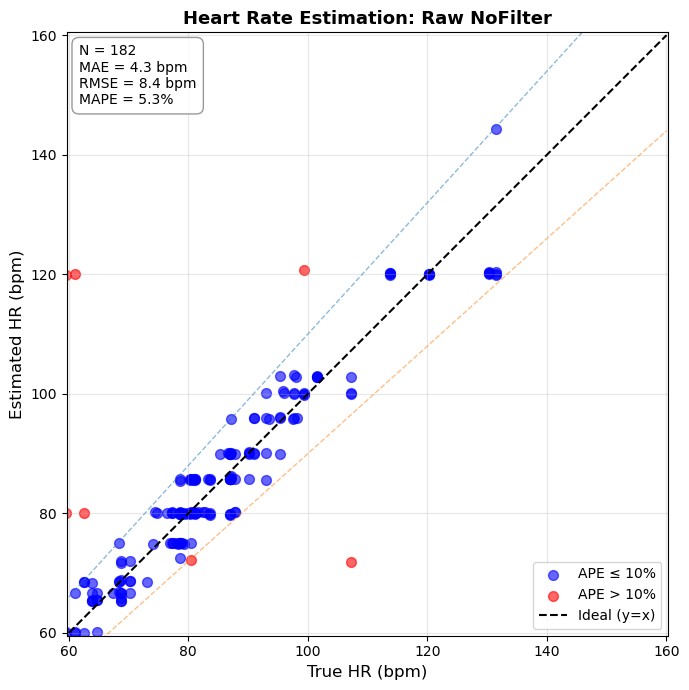

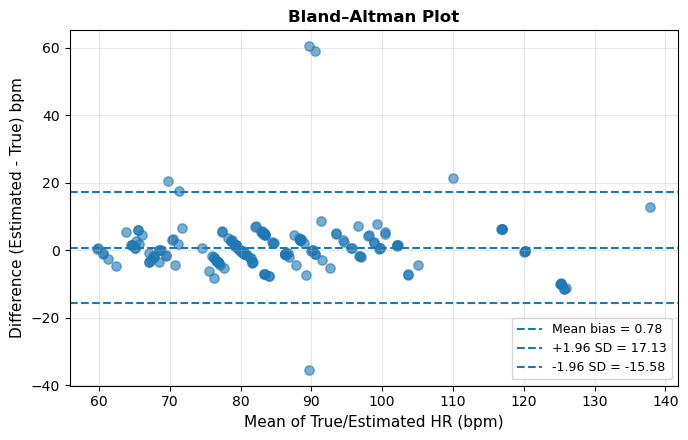

No valid alignment Δt found.


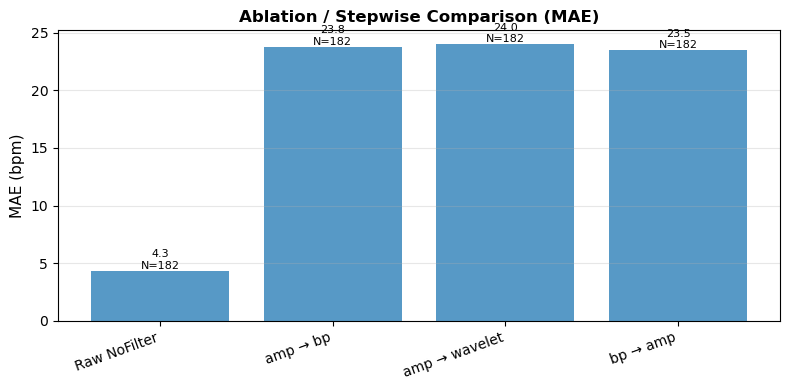


No samples with APE > 10%


In [22]:
results_raw = plot_hr_scatter(all_sample_wave, 
                               method_name="Raw_NoFilter",
                               ape_threshold=10.0,
                               save_fig=False)


繪製方法: Raw_NoFilter

統計指標 (N=182):
  MAE:  4.33 bpm
  RMSE: 8.36 bpm
  Bias: 0.78 bpm
  MAPE: 5.34 %


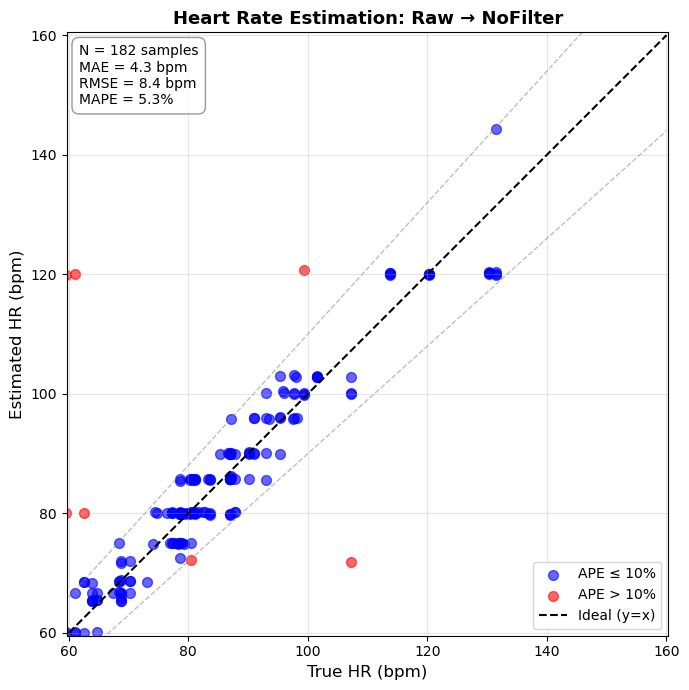


Samples with APE > 10%:
  sample_34: +20.46 bpm (APE = 34.38%)
  sample_37: +58.93 bpm (APE = 96.51%)
  sample_102: +60.35 bpm (APE = 101.40%)
  sample_132: +21.38 bpm (APE = 21.52%)
  sample_139: +17.44 bpm (APE = 27.89%)
  sample_146: -8.20 bpm (APE = 10.20%)
  sample_172: -35.37 bpm (APE = 32.97%)
Total: 7 samples
Sample IDs: [34, 37, 102, 132, 139, 146, 172]


In [ ]:
results_raw = plot_hr_scatter(all_sample_wave, 
                               method_name="Raw_NoFilter",
                               ape_threshold=10.0,
                               save_fig=False)

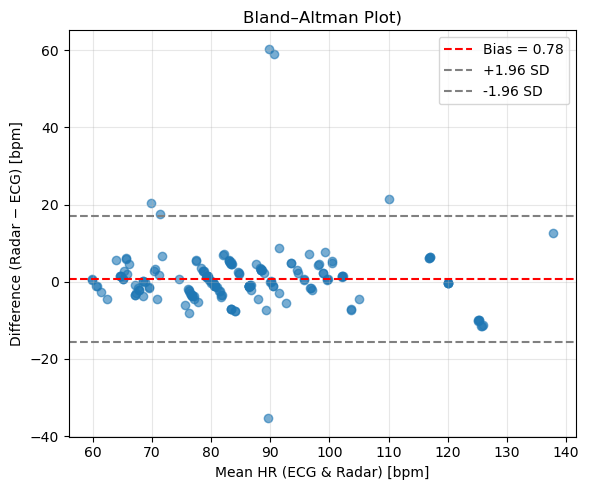

In [ ]:
def plot_bland_altman(all_sample_wave, method_name="Raw_NoFilter"):
    hr_true_list, hr_est_list = [], []

    for num in all_sample_wave:
        hr_true = num.get("ecg_hr_res", np.nan)

        preproc = num.get("preproc_wave", {})
        if method_name not in preproc:
            continue

        df_wave = preproc[method_name]
        t_sec = df_wave["t_sec"].to_numpy(float)
        wave = df_wave["wave"].to_numpy(float)

        if t_sec.size > 1:
            dt = np.median(np.diff(t_sec))
            fs = 1.0 / dt if dt > 0 else 10.0
        else:
            fs = 10.0

        summary = {
            'dataframe': pd.DataFrame({'t_sec': t_sec, 'heartbeat': wave}),
            'fs_Hz': fs,
            'csv': 'temp'
        }

        try:
            cep = analyze_cepstrum(summary, save_plots=False, show_plots=False)
            hr_est = cep["hr_global_bpm"]
        except:
            hr_est = np.nan

        if np.isfinite(hr_true) and np.isfinite(hr_est):
            hr_true_list.append(hr_true)
            hr_est_list.append(hr_est)

    hr_true = np.array(hr_true_list)
    hr_est = np.array(hr_est_list)

    mean_hr = (hr_true + hr_est) / 2
    diff = hr_est - hr_true

    bias = np.mean(diff)
    sd = np.std(diff)
    loa_upper = bias + 1.96 * sd
    loa_lower = bias - 1.96 * sd

    plt.figure(figsize=(6, 5))
    plt.scatter(mean_hr, diff, alpha=0.6)
    plt.axhline(bias, color='r', linestyle='--', label=f"Bias = {bias:.2f}")
    plt.axhline(loa_upper, color='gray', linestyle='--', label="+1.96 SD")
    plt.axhline(loa_lower, color='gray', linestyle='--', label="-1.96 SD")

    plt.xlabel("Mean HR (ECG & Radar) [bpm]")
    plt.ylabel("Difference (Radar − ECG) [bpm]")
    plt.title(f"Bland–Altman Plot)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_bland_altman(all_sample_wave, method_name="Raw_NoFilter")


In [23]:
import numpy as np
import pandas as pd

def _estimate_fs(t_sec: np.ndarray, default_fs: float = 10.0) -> float:
    if t_sec.size > 1:
        dt = np.median(np.diff(t_sec))
        if np.isfinite(dt) and dt > 0:
            return 1.0 / dt
    return default_fs

def hr_fft_peak(wave: np.ndarray, fs: float, hr_min=40, hr_max=180) -> float:
    # remove DC
    x = wave.astype(float)
    x = x - np.mean(x)

    n = x.size
    if n < 8:
        return np.nan

    # rfft
    spec = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    power = (np.abs(spec) ** 2)

    # search in physiological range
    f_min = hr_min / 60.0
    f_max = hr_max / 60.0
    mask = (freqs >= f_min) & (freqs <= f_max)

    if not np.any(mask):
        return np.nan

    idx = np.argmax(power[mask])
    f_peak = freqs[mask][idx]
    return float(f_peak * 60.0)

def hr_autocorr(wave: np.ndarray, fs: float, hr_min=40, hr_max=180) -> float:
    x = wave.astype(float)
    x = x - np.mean(x)
    n = x.size
    if n < 16:
        return np.nan

    # autocorrelation (non-negative lags)
    ac = np.correlate(x, x, mode="full")[n-1:]
    if ac.size < 3:
        return np.nan

    # ignore lag 0
    ac[0] = -np.inf

    # lag range corresponding to HR range
    lag_min = int(np.floor(fs * 60.0 / hr_max))  # higher HR -> smaller lag
    lag_max = int(np.ceil(fs * 60.0 / hr_min))   # lower HR -> larger lag
    lag_min = max(lag_min, 1)
    lag_max = min(lag_max, ac.size - 1)

    if lag_max <= lag_min:
        return np.nan

    lag = np.argmax(ac[lag_min:lag_max+1]) + lag_min
    if lag <= 0:
        return np.nan

    return float(60.0 * fs / lag)

def evaluate_fft_vs_autocorr(all_sample_wave, method_name="Raw_NoFilter",
                             hr_min=40, hr_max=180, default_fs=10.0,
                             verbose=True):
    """
    Evaluate FFT peak and Autocorrelation HR estimators (no waveform reconstruction).
    Uses: num['preproc_wave'][method_name] with columns: t_sec, wave
    True HR: num['ecg_hr_res']
    """

    rows = []
    for num in all_sample_wave:
        hr_true = num.get("ecg_hr_res", np.nan)

        preproc = num.get("preproc_wave", {})
        if method_name not in preproc:
            continue

        df = preproc[method_name]
        if df is None or ("t_sec" not in df.columns) or ("wave" not in df.columns):
            continue

        t_sec = df["t_sec"].to_numpy(float)
        wave = df["wave"].to_numpy(float)
        fs = _estimate_fs(t_sec, default_fs=default_fs)

        if not (np.isfinite(hr_true) and hr_true > 0):
            continue

        hr_fft = hr_fft_peak(wave, fs, hr_min=hr_min, hr_max=hr_max)
        hr_acf = hr_autocorr(wave, fs, hr_min=hr_min, hr_max=hr_max)

        rows.append((hr_true, hr_fft, hr_acf))

    if len(rows) == 0:
        if verbose:
            print("No valid samples.")
        return None

    arr = np.array(rows, dtype=float)
    hr_true = arr[:, 0]
    hr_fft = arr[:, 1]
    hr_acf = arr[:, 2]

    def _metrics(pred, gt):
        m = np.isfinite(pred) & np.isfinite(gt)
        if np.sum(m) == 0:
            return {"N": 0, "MAE": np.nan, "RMSE": np.nan, "Bias": np.nan}
        e = pred[m] - gt[m]
        mae = np.mean(np.abs(e))
        rmse = np.sqrt(np.mean(e**2))
        bias = np.mean(e)
        return {"N": int(np.sum(m)), "MAE": float(mae), "RMSE": float(rmse), "Bias": float(bias)}

    res_fft = _metrics(hr_fft, hr_true)
    res_acf = _metrics(hr_acf, hr_true)

    if verbose:
        print("\n============================================================")
        print(f"Method (input signal): {method_name}")
        print("HR Estimator Metrics (unit: bpm)")
        print("============================================================")
        print(f"{'Estimator':<16} {'N':>5} {'MAE':>10} {'RMSE':>10} {'Bias':>10}")
        print("-"*55)
        print(f"{'FFT peak':<16} {res_fft['N']:>5d} {res_fft['MAE']:>10.2f} {res_fft['RMSE']:>10.2f} {res_fft['Bias']:>10.2f}")
        print(f"{'Autocorr':<16} {res_acf['N']:>5d} {res_acf['MAE']:>10.2f} {res_acf['RMSE']:>10.2f} {res_acf['Bias']:>10.2f}")
        print("============================================================")

    return {"fft_peak": res_fft, "autocorr": res_acf}


In [26]:
evaluate_fft_vs_autocorr(
    all_sample_wave,
    method_name="bp_then_amp"   # 或 "amp_then_bp" 等
)



Method (input signal): bp_then_amp
HR Estimator Metrics (unit: bpm)
Estimator            N        MAE       RMSE       Bias
-------------------------------------------------------
FFT peak           182      19.51      27.99     -13.52
Autocorr           182     106.24     111.25     106.07


{'fft_peak': {'N': 182,
  'MAE': 19.510785245784625,
  'RMSE': 27.985708691781475,
  'Bias': -13.515948144579063},
 'autocorr': {'N': 182,
  'MAE': 106.24411494346386,
  'RMSE': 111.24690936321828,
  'Bias': 106.0713168726767}}